# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

# Used Car Valuation & Price Driver Analysis (WIP)

## Introduction: Business Understanding

My client is a used car dealership looking to optimize its inventory acquisition and pricing strategy. In this analysis, my goal is to identify what features make a vehicle more or less expensive to consumers.

By applying regression modeling to historical vehicle marketplace data, I am quantifying consumer valuation drivers to provide actionable recommendations for the dealership:
* **Trade-in Appraisals:** Establishing accurate baseline offers based on vehicle age, mileage, and condition.
* **Auction Sourcing:** Identifying high-value attributes (such as drivetrains, engine sizes, and vehicle classes) that command market premiums.
* **Title & Risk Penalties:** Measuring the financial depreciation associated with salvage and rebuilt titles.

### Project Roadmap (CRISP-DM Framework)
1. **Business Understanding:** Framing dealership valuation objectives.
2. **Data Understanding & Cleanup:** Profiling raw schema, inspecting missing values, and executing domain-driven imputation.
3. **Data Preparation & Feature Engineering:** Analyzing target correlations, filtering market outliers, applying transformations, and encoding categoricals.
4. **Modeling:** Training and tuning Linear, Ridge, and Lasso regression models.
5. **Evaluation:** Assessing performance metrics ($R^2$, RMSE, MAE) and residual behavior.
6. **Deployment & Dealership Recommendations:** Translating model weights into practical inventory strategies.


In [ ]:
# for work in Google CoLab only
from google.colab import drive
drive.mount('/content/drive')
# replace path accordingly
path = 'drive/MyDrive/all_data/11.1/'

Mounted at /content/drive


In [ ]:
import datetime
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
vehicles_df = pd.read_csv(path + 'data/vehicles.csv')
vehicles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

# Exploratory Data Analysis (EDA)
In this section, we explore the structure, completeness, and initial distributions of the `vehicles_df` dataset to guide our cleaning decisions.

## Phase 1: Data Understanding and Initial Cleanup

In this phase, I explore the raw dataset and examine feature distributions. By understanding what the data represents, I combine industry conventions with my domain background to assess data quality, evaluate missing data patterns, and clean the vehicle inventory.

I achieve this by:
* Performing foundational structural cleaning to prune noisy and redundant attributes.
* Filtering non-viable records to isolate dealership-grade inventory.
* Resolving missing specifications through hierarchical domain imputation.

This establishes a clean, robust baseline for the next phases: Exploratory Data Analysis (EDA) and Feature Engineering.


In [ ]:
df = vehicles_df.copy() # standard naming of starting DataFrame

df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


**Note**: I have created a helper function to output a clean-formatted dump of the NaN values so I can check it repeatedly.

In [ ]:
def get_nan_df(df: pd.DataFrame) -> pd.DataFrame:
  """Returns a numeric DataFrame of missing counts and percentages for all columns."""
  nan_counts = df.isna().sum()
  nan_pct = (nan_counts / len(df) * 100).round(1)

  return pd.DataFrame({'Missing Count': nan_counts, 'Percentage (%)': nan_pct})


def get_nan_summary(
    df: pd.DataFrame, df_name: str = 'DataFrame'
) -> pd.DataFrame:
  """Computes, prints, and returns a sorted summary table of missing values in a DataFrame.

  Args:
      df: The input pandas DataFrame to analyze.
      df_name: Optional name for labeling the output message.

  Returns:
      A sorted pandas DataFrame summarizing problematic columns with missing
      values, including a formatted TOTAL row. Returns an empty DataFrame if no
      missing values exist.
  """
  nan_table = get_nan_df(df)

  # 2. Filter to only columns with missing data and sort descending
  problematic_table = (
      nan_table[nan_table['Missing Count'] > 0]
      .sort_values(by='Missing Count', ascending=False)
      .copy()
  )

  if problematic_table.empty:
    print(f"<{df_name}>: No missing values detected.\n")
    return problematic_table

  # 3. Calculate and append the summary total row
  total_missing = problematic_table['Missing Count'].sum()
  total_pct = problematic_table['Percentage (%)'].sum().round(1)

  problematic_table.loc['TOTAL'] = [total_missing, total_pct]
  problematic_table['Missing Count'] = problematic_table[
      'Missing Count'
  ].astype(int)

  print(f"<{df_name}> Missing Data Breakdown\n")
  return problematic_table

print(get_nan_summary(vehicles_df, "OG DataFrame"))

<OG DataFrame> Missing Data Breakdown

              Missing Count  Percentage (%)
size                 306361            71.8
cylinders            177678            41.6
condition            174104            40.8
VIN                  161042            37.7
drive                130567            30.6
paint_color          130203            30.5
type                  92858            21.8
manufacturer          17646             4.1
title_status           8242             1.9
model                  5277             1.2
odometer               4400             1.0
fuel                   3013             0.7
transmission           2556             0.6
year                   1205             0.3
TOTAL               1215152           284.6


### Feature Selection and Column Pruning

To reduce dimensionality and eliminate uninformative noise, the following features are dropped prior to modeling:
* **`id`**: It is not clear where this value is populated from. However, we have no reason to keep it when a DataFrame automatically creates its own. I noticed that the values are quite long so we can save some space by using the automatically generated ones rather than using `set_index`
* **`VIN` (Unique Identifier):** Vehicle Identification Numbers have near 1:1 cardinality with dataset rows. They carry zero generalizable predictive signal for linear regression and introduce 37.7% missingness. We rely on standard dataframe indexing instead.
* **`size` (High Sparsity & Proxy Redundancy):** Over 71.8% of the data in this column is missing. Furthermore, vehicle dimensions are effectively captured by the `type` feature (such as sedan, pickup, or SUV) and specific `model` indicators, making aggressive synthetic imputation unnecessary.
* **`paint_color` (Negligible Mass-Market Valuation Impact):** Color choice accounts for marginal price variance in standard used vehicle transactions while introducing 30.5% missingness. Excluding it prevents overparameterization across nominal categories.


In [ ]:
# Begin construction of cleaned dataframe
df.drop(['id', 'VIN', 'size', 'paint_color'], axis=1, inplace=True)

How about the `region` vs `state`? These features seem like they would have some overlap.

In [ ]:
print(df['region'].unique())
print(df['state'].unique())

['prescott' 'fayetteville' 'florida keys' 'worcester / central MA'
 'greensboro' 'hudson valley' 'medford-ashland' 'erie' 'el paso'
 'bellingham' 'skagit / island / SJI' 'la crosse' 'auburn' 'birmingham'
 'dothan' 'florence / muscle shoals' 'gadsden-anniston'
 'huntsville / decatur' 'mobile' 'montgomery' 'tuscaloosa'
 'anchorage / mat-su' 'fairbanks' 'kenai peninsula' 'southeast alaska'
 'flagstaff / sedona' 'mohave county' 'phoenix' 'show low' 'sierra vista'
 'tucson' 'yuma' 'fort smith' 'jonesboro' 'little rock' 'texarkana'
 'bakersfield' 'chico' 'fresno / madera' 'gold country' 'hanford-corcoran'
 'humboldt county' 'imperial county' 'inland empire' 'los angeles'
 'mendocino county' 'merced' 'modesto' 'monterey bay' 'orange county'
 'palm springs' 'redding' 'reno / tahoe' 'sacramento' 'san diego'
 'san luis obispo' 'santa barbara' 'santa maria' 'SF bay area'
 'siskiyou county' 'stockton' 'susanville' 'ventura county'
 'visalia-tulare' 'yuba-sutter' 'boulder' 'colorado springs' 'denve

### Dropping `region` Feature
I drop `region` because its 400+ granular local sub-markets introduce high-cardinality sparsity and risk model overfitting. From experience, I know that state lines do affect car prices, so the `state` feature should be good enough to capture geographic price differences. In fact, I may think about creating state groupings as well (see Phase 2).


In [ ]:
df = df.drop(columns=["region"])

### Dropping Problematic Rows: `year` and `odometer`

Is there a possibility of removing any other columns? I don't think so, but I do think there is scope for removing **pieces** of other columns—specifically `year` and `title_status`.

Anyone with real-life experience buying and selling cars knows that `year` directly drives price and is very important. However, it is difficult to impute a value. As a car fan, I know it is technically possible to guess a year range from a combination of other columns (and as we'll see later, the `model` column actually includes the year for some vehicles). But building a custom filter or regex imputation function would be overly complicated, especially since other columns have missing values too. In fact, `year` is needed to help impute those other columns, which creates a circular dependency problem.

Since missing `year` values account for only **0.3%** of the dataset, the cleanest choice is to simply drop the records missing a year.

For the exact same reason, I am dropping missing values in `odometer`—another critical driver of used car prices.


In [ ]:
df.dropna(subset=['year', 'odometer'], inplace=True)

# Validation
print(
    f"NaN Counts: Year: {df['year'].isna().sum()},"
    f" Odometer: {df['odometer'].isna().sum()}"
)


NaN Counts: Year: 0, Odometer: 0


This looks much better—there are no more `NaN` values. Following ML best practices, `vehicle_age` is typically preferred over raw `year`.

### Transforming `year` to `vehicle_age`

While both metrics carry the exact same mathematical correlation with price, vehicle age directly captures annual depreciation—which is how dealerships evaluate inventory. It grounds our baseline price at a brand-new car (age 0) and prevents model drift as new inventory arrives over time.

I am transforming this data dynamically using the current calendar year via a lookup so this pipeline can run anytime without hardcoded dates.

In [ ]:
current_year = datetime.datetime.now().year
df['vehicle_age'] = current_year - df['year']

# verify a sample to ensure the years are correct
df[['year', 'vehicle_age']].sample(5)


,year,vehicle_age
47001,2002.0,24.0
398325,2019.0,7.0
238271,2018.0,8.0
283314,2008.0,18.0
276047,2018.0,8.0


The age is lining up. We can now drop the original `year`.

In [ ]:
df.drop(columns=['year'], inplace=True)

Turning my attention to the `title_status` column now:

In [ ]:
print(df['title_status'].unique())

['clean' 'rebuilt' 'lien' nan 'salvage' 'missing' 'parts only']


### Handling `title_status`

I have filtered out `NaN` and `parts only` records (<2% of data) to keep the model focused strictly on dealership-grade inventory.

Retaining `salvage`, `rebuilt`, `lien`, and `clean` titles will allow the model to accurately calculate the price penalties of title defects. In other words, it will provide valuable information on the negative correlations in this column as well.

In [ ]:
# This automatically drops 'missing', 'parts only', and 'nan'
valid_titles = ['clean', 'rebuilt', 'lien', 'salvage']
df = df[df['title_status'].isin(valid_titles)]

Now examining the `condition` colum:

In [ ]:
print(df['condition'].unique())

['good' 'excellent' 'fair' nan 'like new' 'new' 'salvage']


In [ ]:
print(get_nan_summary(df, "Cleaned DF: VIN,paint, size, title, year, odometer"))

<Cleaned DF: VIN,paint, size, title, year, odometer> Missing Data Breakdown

              Missing Count  Percentage (%)
cylinders            173170            41.9
condition            168249            40.7
drive                124706            30.2
type                  90775            22.0
manufacturer          15898             3.8
model                  5063             1.2
transmission           1643             0.4
fuel                   1623             0.4
TOTAL                581127           140.6


### Handling Missing `condition` Data
Domain & Statistical Rationale:
* Empirical Driver of Value: Vehicle condition is an established driver of market valuation (e.g., standard automotive indices like Kelley Blue Book).
* Avoiding Synthetic Distortion: Because condition is subjective and missing in ~41% of records, imputing values using other features or filling via frequency ratios risks injecting artificial bias and degrading feature correlations.
* Preserving Real-World Generalization: Creating an explicit 'Unknown' category enables the linear model to quantify the baseline value of unspecified listings directly, allowing the dealership to price incoming inventory even when physical condition ratings are omitted.

In [ ]:
df['condition'] = df['condition'].fillna('Unknown')

### Domain-Driven Imputation: `manufacturer`, `model`, and `vehicle_age`

As a car enthusiast, my domain knowledge tells me that a vehicle's core specifications are tightly determined by its **make, model, and year**.

* For example, knowing a car is a 2018 Ford Mustang gives us a very accurate proxy for its drivetrain (`rwd`), engine options, and body type (`coupe`/`convertible`).

Rather than guessing or filling missing categorical values with global averages, I am using a **hierarchical conditional imputation** strategy across our remaining problematic columns (`drive`, `cylinders`, and `type`).

I am restricting conditional imputation to two precise tiers:
1. `manufacturer` + `model` + `vehicle_age` (Generation Mode)
2. `manufacturer` + `model` (Model-level Mode)

Any edge cases that cannot be resolved at the model level are assigned to an explicit `'Unknown'` category.

Before proceeding with the imputation, the data must be examined. This will show any patterns to resolve the imputation. If nothing else, it can also be used as a baseline to see what happens afterward.

In [ ]:
# let's examine the columns before any transformation

inspect_cols = ['cylinders', 'type', 'transmission', 'fuel']

for col in inspect_cols:
  print(f"\n--- Column: {col} ---")
  print("Unique values:")
  print(df[col].unique())
  print("\nValue Counts (including NaN):")
  print(df[col].value_counts(dropna=False).head(10))


--- Column: cylinders ---
Unique values:
['8 cylinders' '6 cylinders' nan '4 cylinders' '5 cylinders' 'other'
 '3 cylinders' '10 cylinders' '12 cylinders']

Value Counts (including NaN):
cylinders
NaN             173170
6 cylinders      90550
4 cylinders      74199
8 cylinders      69990
5 cylinders       1677
10 cylinders      1415
other             1158
3 cylinders        618
12 cylinders       197
Name: count, dtype: int64

--- Column: type ---
Unique values:
['pickup' 'truck' 'other' nan 'coupe' 'SUV' 'hatchback' 'mini-van' 'sedan'
 'offroad' 'bus' 'van' 'convertible' 'wagon']

Value Counts (including NaN):
type
NaN          90775
sedan        83982
SUV          73744
pickup       42390
truck        34160
other        21293
coupe        18679
hatchback    16274
wagon        10415
van           7872
Name: count, dtype: int64

--- Column: transmission ---
Unique values:
['other' 'automatic' 'manual' nan]

Value Counts (including NaN):
transmission
automatic    325056
other         6

### Standardizing and Imputing `type`, `cylinders`, `transmission`, and `fuel`

Inspecting the unique value distributions revealed key opportunities for data refinement:

* **Category Consolidation (`type`):** `pickup` and `truck` describe the same functional vehicle class in used car markets. Combining `pickup` into `truck` prevents redundant feature splitting.
* **Extracting Numeric Cylinders:** Because cylinder counts represent physical engine size, I extracted numeric integers (`4`, `6`, `8`) to allow the linear model to capture linear scale rather than treating each engine format as an isolated nominal category.

I can proceed with the Missing values across `type`, `cylinders`, `transmission`, and `fuel` through the hierarchical imputation suggested above: `make + model + age` $\rightarrow$ `make + model` $\rightarrow$ `make`.


Unfortunatelly, looking at our `NaN` values above, `manufacturer` and `model` themselves have some empty spots. I wanted to examine this first.

In [ ]:
target_indices = [384, 2241, 2826, 3420]

# Pull exact target rows
target_rows = df.loc[target_indices, ['manufacturer', 'model']]

# Pull reproducible random sample for the rest
random_sample = (
    df.drop(index=target_indices)[['manufacturer', 'model']]
    .sample(10, random_state=42)
)

# Display combined sample
final_sample = pd.concat([target_rows, random_sample])
print("Target Edge Cases + Random Sample:")
print(final_sample)

Target Edge Cases + Random Sample:
       manufacturer                       model
384             bmw                          x6
2241           ford                 f150 lariat
2826      chevrolet              silverado 2500
3420           ford   f150 super cab xlt pickup
320807         ford  f-250 super duty lariat li
388767         mini                    cooper s
400589          bmw                x1 xdrive28i
40598       lincoln         continental reserve
181019         ford    f350 super duty crew cab
82239          ford        super duty f-350 drw
176615         ford                      taurus
145420       toyota                  highlander
13062        toyota                         NaN
190276      hyundai                      sonata


Unfortunately `manufacturer` itself has a high percentage of missing values. Further inspection of the groups revealed that missing `manufacturer` values are often leaked directly into the `model` column.

Meanwhile, the data in `model` is highly corrupted with typos (e.g., 'yundai'), promotional noise, emojis, Cyrillic characters, and mathematical alphanumeric fonts. Let's see all values that are not alphanumeric values:



In [ ]:
non_ascii_models = df[
    df['model'].astype(str).str.contains(r'[^\x00-\x7F]', regex=True, na=False)
][['manufacturer', 'model']]

print("Non-ASCII / Stylized Models Found:")
print(non_ascii_models.head(20))

Non-ASCII / Stylized Models Found:
         manufacturer                        model
16507             NaN  🔥GMC Sierra 1500 SLE🔥 4X4 🔥
21194          nissan                     altima ￼
22997          toyota                    corolla￼￼
23007          nissan                     altima ￼
39447             NaN                         50’s
41153   mercedes-benz            c-class c 43 amg®
44302       chevrolet           12’ flatbed atruck
51933             NaN                 1937 Willy’s
57669            ford     flex sel sport – 3rd row
89715        chrysler          300 touring édition
96985          toyota                  corolla “s”
99400             NaN         𝓜𝓮𝓻𝓬𝓮𝓭𝓮𝓼 𝓫𝓮𝓷𝔃 𝓶𝓵 350
139481            NaN               VMI-CHRYSLER-♿
139801       chrysler                        ♿ vmi
140276            kia                 ​​sorento lx
142548       chrysler                    / vmi / ♿
142936       chrysler                    * vmi * ♿
143075       chrysler                    * vmi 

### Dropping Incomplete and Malformed `manufacturer`/`model` Rows

I initially considered defining increasingly complex extraction algorithms to parse missing makes and models—such as fuzzy string matching to detect known models, or creating lookup dictionaries for shorthand slang (e.g., `vette` for `corvette` or `n altima` for `nissan`).

However, looking closely at the data revealed several real-world text challenges:
* **Embedded Make and Year:** The manufacturer name was often included inside the model string rather than as the first word because sellers listed the manufacturing year first.
* **Merged Brand Strings:** Some listings had the make and model clubbed together without spaces.
* **Unicode and Emojis:** Characters like stylized script (`𝓜𝓮𝓻𝓬𝓮𝓭𝓮𝓼`) and emojis (`🔥`, `♿`) were scattered across listings.
* **Garbage and Raw Identifier Data:** Several entries contained raw VIN strings or blank fields rather than actual vehicle names, such as:
  * `('5fnyf4h21eb053247', '')`
  * `('5n1aa0ne3bn614984', '')`
  * `('5nmsh73e27h004000', '')`

Here I was forced to take a step back. In our current dataset, missing `manufacturer` data accounts for **3.8%** (15,898 records) while missing `model` accounts for **1.2%** (5,063 records). Combined with malformed entries, they represent only ~5% of our rows.

Attempting to build and maintain a custom string-matching extraction algorithm is highly inefficient and risks injecting heuristic errors. Dropping these missing, malformed, and non-ASCII rows leaves over 400,000 statistically clean records—giving us a robust dataset without introducing synthetic data noise.

Therefore, I am dropping records missing a `manufacturer` or `model`. As a final safeguard, I sanitize any non-ASCII characters, emojis, and unicode artifacts across the remaining text to keep our categories clean.

In [ ]:
print(f"Before drop: {len(df):,} rows")

# 1. Drop rows with missing manufacturer or model
df = df.dropna(subset=["manufacturer", "model"]).reset_index(drop=True)

# 2. Filter out non-ASCII characters (emojis, math script fonts, etc.)
ascii_mask = (
    df["model"].astype(str).str.contains(r"^[ -~]+$", regex=True, na=False)
    & df["manufacturer"]
    .astype(str)
    .str.contains(r"^[ -~]+$", regex=True, na=False)
)
df = df[ascii_mask].reset_index(drop=True)

# 3. Clean casing and whitespace
df["manufacturer"] = df["manufacturer"].astype(str).str.lower().str.strip()
df["model"] = df["model"].astype(str).str.lower().str.strip()

print(f"After drop: {len(df):,} rows")


Before drop: 412,974 rows
After drop: 391,963 rows


Validating:

In [ ]:
non_ascii_models = df[
    df['model'].astype(str).str.contains(r'[^\x00-\x7F]', regex=True, na=False)
    | df['manufacturer']
    .astype(str)
    .str.contains(r'[^\x00-\x7F]', regex=True, na=False)
][['manufacturer', 'model']]

print('Non-ASCII / Stylized Models Found:')
print(non_ascii_models.head(20))


Non-ASCII / Stylized Models Found:
Empty DataFrame
Columns: [manufacturer, model]
Index: []


Our text is free of non-ascii. As an additional baseline:

In [ ]:
pre_imputation_df = get_nan_df(df)

print(get_nan_summary(
    df, 'Cleaned DF: Pre-Imputation Snapshot'
))

<Cleaned DF: Pre-Imputation Snapshot> Missing Data Breakdown

              Missing Count  Percentage (%)
cylinders            162945            41.6
drive                115714            29.5
type                  82503            21.0
fuel                   1566             0.4
transmission           1556             0.4
TOTAL                364284            92.9


### Next Step: Hierarchical Imputation

With `manufacturer`, `model`, and `vehicle_age` now fully validated and clean, I am proceeding with my multi-tiered hierarchical mode imputation to fill the remaining missing values across `cylinders`, `drive`, `type`, `fuel`, and `transmission`.


In [ ]:
# 1. Snapshot NaN counts before imputation for verification
impute_target_cols = [
    'drive',
    'cylinders',
    'type',
    'transmission',
    'fuel',
]
pre_impute_nans = df[impute_target_cols].isna().sum()

# 2. Consolidate 'pickup' into 'truck' in body type before mode calculations
df['type'] = df['type'].replace({'pickup': 'truck'})


# Helper function to compute mode Series safely
def get_mode_series(group_series: pd.Series) -> pd.Series:
  valid = group_series.dropna()
  return (
      group_series.fillna(valid.mode()[0])
      if not valid.empty and not valid.mode().empty
      else group_series
  )


# 3. Hierarchical Mode Imputation (Make+Model+Age -> Make+Model)
structural_cols = ['drive', 'cylinders', 'type', 'transmission', 'fuel']

for col in structural_cols:
  # 3.1: Most granular (Make + Model + Age)
  m1 = df.groupby(['manufacturer', 'model', 'vehicle_age'])[col].transform(
      get_mode_series
  )

  # 3.2: Make + Model
  m2 = df.groupby(['manufacturer', 'model'])[col].transform(get_mode_series)

  # 3.3: Apply hierarchically back to the column
  df[col] = df[col].fillna(m1).fillna(m2)

In [ ]:
post_imputation_df = get_nan_df(df)

print(get_nan_summary(
    df, 'Cleaned DF: Post-Imputation Snapshot'
))

pre = pre_imputation_df.drop(index='TOTAL', errors='ignore')
post = post_imputation_df.drop(index='TOTAL', errors='ignore')

# 1. Align all column names that had missing values before imputation
problem_cols = pre[pre['Missing Count'] > 0].index

# 2. Extract counts; if absent in post, count is 0 (100% recovered)
before_counts = pre.loc[problem_cols, 'Missing Count'].astype(int)
after_counts = (
    post['Missing Count'].reindex(problem_cols).fillna(0).astype(int)
)

# 3. Calculate Delta (number of recovered missing cells) and Recovery %
delta = before_counts - after_counts
recovery_pct = (
    (delta / before_counts * 100).fillna(100.0).round(1).astype(str) + '%'
)

comparison_df = pd.DataFrame(
    {
        f'Pre Count': before_counts,
        f'Post Count': after_counts,
        'Δ Recovered': delta,
        'Recovery (%)': recovery_pct,
    },
    index=problem_cols,
).sort_values(by='Δ Recovered', ascending=False)

# 4. Add summary TOTAL row
total_before = before_counts.sum()
total_after = after_counts.sum()
total_delta = total_before - total_after
total_recovery_pct = (
    f'{round((total_delta / total_before * 100), 1) if total_before > 0 else 100.0}%'
)

comparison_df.loc['TOTAL'] = [
    total_before,
    total_after,
    total_delta,
    total_recovery_pct,
]

print(comparison_df)

<Cleaned DF: Post-Imputation Snapshot> Missing Data Breakdown

              Missing Count  Percentage (%)
cylinders             33289             8.5
drive                 18017             4.6
type                   6455             1.6
fuel                   1024             0.3
transmission             62             0.0
TOTAL                 58847            15.0
              Pre Count  Post Count  Δ Recovered Recovery (%)
cylinders        162945       33289       129656        79.6%
drive            115714       18017        97697        84.4%
type              82503        6455        76048        92.2%
transmission       1556          62         1494        96.0%
fuel               1566        1024          542        34.6%
TOTAL            364284       58847       305437        83.8%


### Hierarchical Imputation Results & Assigning `'Unknown'` Sentinels

The hierarchical conditional imputation successfully recovered **305,437 missing values** across my dataset, achieving an overall **83.8% recovery rate** based on make, model, and age groupings. Specifically, `drive` recovered **84.4%** (97,697 records) and `cylinders` recovered **79.6%** (129,656 records), mapping them cleanly back to their true mechanical specifications.

For the remaining ~16% of missing categorical entries, I am opting to fill them with an explicit `'Unknown'` sentinel rather than dropping rows or forcing synthetic guesses:

* **Preventing Sample Attrition:** Dropping rows with any remaining missing field would discard tens of thousands of otherwise complete vehicle records, reducing statistical power.
* **Avoiding Fabricated Variance:** When an obscure or vintage vehicle lacks a clear mode in its cohort, guessing a category injects artificial assumptions.
* **Real-World Inference (Out-of-Distribution Handling):** In production, dealerships frequently encounter trade-in listings with omitted attributes. Giving the linear regression model an explicit `'Unknown'` category allows it to learn an unpenalized baseline coefficient for missing entries.


In [ ]:
# Fill remaining NaNs across all categorical features with 'Unknown'
impute_cols = [
    'drive',
    'cylinders',
    'type',
    'transmission',
    'fuel',
]
df[impute_cols] = df[impute_cols].fillna('Unknown')

# Confirm all NaNs in categorical columns are resolved
print(get_nan_summary(df, 'Final Cleaned DF: Post Imputation+Unknown Fill'))

<Final Cleaned DF: Post Imputation+Unknown Fill>: No missing values detected.

Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []


In [ ]:
unknown_cols = impute_cols + ['condition']

for col in unknown_cols:
  print(f"\n--- Column: {col} ---")
  print("Unique values:")
  print(df[col].unique())
  print("\nValue Counts (including NaN):")
  print(df[col].value_counts(dropna=False).head(10))


--- Column: drive ---
Unique values:
['4wd' 'rwd' 'Unknown' 'fwd']

Value Counts (including NaN):
drive
4wd        168136
fwd        136378
rwd         69432
Unknown     18017
Name: count, dtype: int64

--- Column: cylinders ---
Unique values:
['8 cylinders' '6 cylinders' 'Unknown' '4 cylinders' '5 cylinders'
 '3 cylinders' '10 cylinders' 'other' '12 cylinders']

Value Counts (including NaN):
cylinders
6 cylinders     133031
4 cylinders     121021
8 cylinders      98105
Unknown          33289
5 cylinders       2220
10 cylinders      1804
other             1532
3 cylinders        830
12 cylinders       131
Name: count, dtype: int64

--- Column: type ---
Unique values:
['truck' 'other' 'SUV' 'coupe' 'hatchback' 'mini-van' 'sedan' 'offroad'
 'van' 'convertible' 'Unknown' 'wagon' 'bus']

Value Counts (including NaN):
type
sedan          102703
SUV             93740
truck           92181
other           20828
coupe           20578
hatchback       17490
wagon           11831
van            

### Consolidating `'Unknown'` and `'other'` Categories

Examining the category distributions shows that both `'other'` and `'Unknown'` represent unclassified or non-standard listings. In columns like `transmission` (62 instances) and `fuel` (1,024 instances), retaining `'Unknown'` as an isolated category introduces unnecessary sparsity without providing distinct predictive value.

To keep the feature space parsimonious and prevent the linear model from fitting redundant coefficients, I am consolidating all `'Unknown'` labels into the existing `'other'` category across `transmission`, `fuel`, `type`, and `drive`.


In [ ]:
for col in unknown_cols:
  if col in df.columns:
    df[col] = df[col].replace({'Unknown': 'other', 'unknown': 'other'})
    # Ensure all strings are lowercase
    df[col] = df[col].astype(str).str.lower()

# Verification check
for col in unknown_cols:
  print(f"\n--- Consolidated Counts for {col} ---")
  print(df[col].value_counts())


--- Consolidated Counts for drive ---
drive
4wd      168136
fwd      136378
rwd       69432
other     18017
Name: count, dtype: int64

--- Consolidated Counts for cylinders ---
cylinders
6 cylinders     133031
4 cylinders     121021
8 cylinders      98105
other            34821
5 cylinders       2220
10 cylinders      1804
3 cylinders        830
12 cylinders       131
Name: count, dtype: int64

--- Consolidated Counts for type ---
type
sedan          102703
suv             93740
truck           92181
other           27283
coupe           20578
hatchback       17490
wagon           11831
van              9853
convertible      8176
mini-van         6937
offroad           677
bus               514
Name: count, dtype: int64

--- Consolidated Counts for transmission ---
transmission
automatic    311674
other         59433
manual        20856
Name: count, dtype: int64

--- Consolidated Counts for fuel ---
fuel
gas         330762
other        29559
diesel       25079
hybrid        4985
elect

In [ ]:
print(vehicles_df.info())
print(get_nan_summary(vehicles_df, 'OG DataFrame'))

print('='*22+'+++'+'='*22)

print(df.info())
print(get_nan_summary(df, 'Cleaned and Imputed DataFrame'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

## Summary: Data Understanding & Cleanup

By removing uninformative identifiers (`VIN`, `size`, `paint_color`), pruning extreme noise (<2% of titles and missing years), and dropping unrecoverable makes/models, I reduce the dataset from **426,880 rows down to 391,963 clean records** (a net retention of 91.8%).

Through hierarchical domain imputation, all 1.2+ million initial missing instances across `drive`, `cylinders`, `type`, `transmission`, and `fuel` are completely resolved to **0 missing values**, with subjective missing condition entries safely captured in an explicit `other`/`Unknown` category (160,101 rows).

With a fully populated and statistically clean dataset of 391,963 records across 15 structured features, I proceed to the next phase of EDA.


In [ ]:
# store phase1 result for restarts
def create_parquet_path(filename: str) -> str:
  return os.path.join(
      path,
      "data",
      "output",
      filename+".parquet"
  )

parquet_file_path = create_parquet_path('phase1_vehicle_data_cleaned')

In [ ]:
df.to_parquet(parquet_file_path, index=False)
print(f"Saved cleaned dataset to: {parquet_file_path}")

Saved cleaned dataset to: drive/MyDrive/all_data/11.1/data/output/vehicle_data_cleaned_phase1.parquet


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

## Phase 2: Feature Engineering, Outlier Filtering, and Model Preparation

Now that initial data cleaning is complete—missing values resolved, extraneous columns dropped, and malformed text entries pruned—I am transitioning from raw data cleansing into **feature engineering and dataset preparation**.

The objective of this phase is to produce a fully sanitized, **model-ready DataFrame** for Linear Regression.

### Phase 2 Workflow:
1. **Outlier Mitigation:** Filtering extreme pricing anomalies ($0 placeholders, multi-million dollar listings) and unrealistic mileage caps to satisfy linear regression assumptions.
2. **Feature Transformations & Encoding:** Converting nominal classes to dummy variables (`pd.get_dummies`) and evaluating log transformations for right-skewed continuous distributions.


In [ ]:
# Check if 'df' is already loaded in memory; if not, read from parquet
prefix = 'Previously had'
if "df" not in locals() or df is None:
  if os.path.exists(parquet_file_path):
    df = pd.read_parquet(parquet_file_path)
    prefix = 'Loaded'
  else:
    raise FileNotFoundError(f'Parquet checkpoint not found at: {parquet_file_path}')

# Expected 391,963
print(f'{prefix} {len(df):,} cleaned records. Ready for Phase 2!')

# store a copy of the cleaned df just in case. Use cleaned_df for Phase 2
cleaned_df = df
cleaned_df.info()

Loaded 391,963 cleaned records. Ready for Phase 2!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391963 entries, 0 to 391962
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         391963 non-null  int64  
 1   manufacturer  391963 non-null  object 
 2   model         391963 non-null  object 
 3   condition     391963 non-null  object 
 4   cylinders     391963 non-null  object 
 5   fuel          391963 non-null  object 
 6   odometer      391963 non-null  float64
 7   title_status  391963 non-null  object 
 8   transmission  391963 non-null  object 
 9   drive         391963 non-null  object 
 10  type          391963 non-null  object 
 11  state         391963 non-null  object 
 12  vehicle_age   391963 non-null  float64
dtypes: float64(2), int64(1), object(10)
memory usage: 38.9+ MB


### Phase 2.1: Continuous Feature Preparation and Outlier Filtering

Linear regression assumes linear relationships and is sensitive to extreme values. In this step, I am addressing our primary continuous variables: the target variable `price` and the features `odometer`, and `vehicle_age`.

Inspecting the distributions should reveal trends and any anomalous data.

In [ ]:
# starting with the basic stats
continuous = ['price', 'vehicle_age', 'odometer']

# cleaned_df[continuous].describe() # this showed scientific notation

# creating a cleaned copy...
desc = df[continuous].describe().copy()

# Format columns individually
# Price and odometer: standard comma-separated integers (no scientific notation)
# Vehicle age: integer formatting with no decimals
desc['price'] = desc['price'].apply(lambda x: f'{x:,.0f}')
desc['odometer'] = desc['odometer'].apply(lambda x: f'{x:,.0f}')
desc['vehicle_age'] = desc['vehicle_age'].apply(lambda x: f'{x:.0f}')

print("Descriptive Statistics (Formatted):")
print(desc)

Descriptive Statistics (Formatted):
               price vehicle_age    odometer
count        391,963      391963     391,963
mean          63,720          14      96,050
std       11,414,143           9     187,156
min                0           4           0
25%            5,995           9      38,063
50%           13,997          12      85,662
75%           26,592          17     133,196
max    3,736,928,711         126  10,000,000


### Summary Statistics and Initial Anomaly Detection

Reviewing the summary statistics for continuous variables reveals some obvious anomalies:

* **Placeholder Zeroes:** Both `price` and `odometer` contain minimums of `0`, which represent free/placeholder listings rather than actual vehicle sales.
* **Severe Right-Skewed Outliers:** `price` peaks at an unrealistic \$3.73 **billion** (forcing the mean to \$63,720 despite a median of \$13,997), while `odometer` reaches 10 **million** miles.
* **Age Discrepancies:** `vehicle_age` spans up to 126 years, capturing extreme vintage outliers that do not reflect standard dealership stock

I want to take a look at the breakdown in more detail.

In [ ]:
# quick helper function to clean output the districution
def print_interval_distribution(
    df: pd.DataFrame, column: str, bins: list, labels: list
) -> pd.DataFrame:
  """
  Bins a continuous column using `pd.cut` into defined intervals and returns
  count + percentage breakdown.
  """
  binned_series = pd.cut(
      df[column],
      bins=bins,
      labels=labels,
      right=True,
      include_lowest=True,
  )

  counts = binned_series.value_counts(sort=False)
  percentages = (counts / len(df) * 100).round(2)

  summary_table = pd.DataFrame({
      "Range": labels,
      "Record Count": counts.values,
      "Percentage (%)": percentages.values,
  })

  print(f"\n==================================================")
  print(f"  Distribution Breakdown: '{column}'")
  print(f"==================================================")
  print(summary_table.to_string(index=False))
  return summary_table


In [ ]:
# price intervals
price_bins = [-np.inf, -0.001, 0.0, 499.0, 2999.0, 9999.0, 24999.0, 49999.0,
              99999.0, 149999.0, 349999.0, 549999.0, 999_999.0, np.inf]

price_labels = [
    "< $0 (Negative Anomaly)",
    "$0 (Free / Placeholder)",
    "$1 - $499 (Scrap / Down Payment)",
    "$500 - $2,999 (Budget / Beater)",
    "$3,000 - $9,999 (Economy Used)",
    "$10,000 - $24,999 (Mid-Market Core)",
    "$25,000 - $49,999 (Late-Model / Premium)",
    "$50,000 - $99,999 (Luxury / Heavy Duty)",
    "$100,000 - $149,999 (Max-Spec Luxury)",
    "$150,000 - $349,999 (Exotic / Ultra Luxury)",
    "$350,000 - $549,999 (Ultra Exotic / Supercar)",
    "$550,000 - $999,999 (Hypercar Segment)",
    "> $1,000,000 (Collector's Item or Error)",  # (999,999.0 to +inf]
]

price_summary_pre = print_interval_distribution(
    df, "price", price_bins, price_labels
)


  Distribution Breakdown: 'price'
                                        Range  Record Count  Percentage (%)
                      < $0 (Negative Anomaly)             0            0.00
                      $0 (Free / Placeholder)         28745            7.33
             $1 - $499 (Scrap / Down Payment)          7541            1.92
              $500 - $2,999 (Budget / Beater)         18526            4.73
               $3,000 - $9,999 (Economy Used)        102402           26.13
          $10,000 - $24,999 (Mid-Market Core)        128440           32.77
     $25,000 - $49,999 (Late-Model / Premium)         95326           24.32
      $50,000 - $99,999 (Luxury / Heavy Duty)         10592            2.70
        $100,000 - $149,999 (Max-Spec Luxury)           285            0.07
  $150,000 - $349,999 (Exotic / Ultra Luxury)            70            0.02
$350,000 - $549,999 (Ultra Exotic / Supercar)             2            0.00
       $550,000 - $999,999 (Hypercar Segment)        

In [ ]:
# odometer intervals
odo_bins = [-np.inf, -0.0001, 0, 499, 29999, 74999, 149999, 249999, 349999, np.inf]
odo_labels = [
    '<0 Miles (Negative Anomaly / Data Error)',
    '0 Miles (Zero Placeholder)',
    '1 - 499 Miles (New/Returned Car)',
    '500 - 29,999 Miles (Very Low / Near New)',
    '30,000 - 74,999 Miles (Standard Used)',
    '75,000 - 149,999 Miles (Average Commuter)',
    '150,000 - 249,999 Miles (High Mileage)',
    '250,000 - 349,999 Miles (Very High Mileage)',
    '>350,000 Miles (Extreme Outlier / Data Error)',
]

odo_summary_pre = \
  print_interval_distribution(df, 'odometer', odo_bins, odo_labels)


  Distribution Breakdown: 'odometer'
                                        Range  Record Count  Percentage (%)
     <0 Miles (Negative Anomaly / Data Error)             0            0.00
                   0 Miles (Zero Placeholder)          1299            0.33
             1 - 499 Miles (New/Returned Car)          5482            1.40
     500 - 29,999 Miles (Very Low / Near New)         70375           17.95
        30,000 - 74,999 Miles (Standard Used)         96063           24.51
    75,000 - 149,999 Miles (Average Commuter)        147418           37.61
       150,000 - 249,999 Miles (High Mileage)         65446           16.70
  250,000 - 349,999 Miles (Very High Mileage)          4674            1.19
>350,000 Miles (Extreme Outlier / Data Error)          1206            0.31


In [ ]:
# year (vehicle age) intervals
age_bins = [-np.inf, -1, 0, 3, 7, 15, 25, 50, 75, 100, 125, np.inf]

age_labels = [
    '<0 Years (Future Year / Data Error)',
    '0 Years (Current Year / Brand New)',
    '1 - 3 Years (Late Model / Off-Lease)',
    '4 - 7 Years (Standard Used)',
    '8 - 15 Years (Aged Inventory)',
    '16 - 25 Years (Budget Older)',
    '26 - 50 Years (Modern Classic)',
    '51 - 75 Years (Vintage / Post-War Classic)',
    '76 - 100 Years (Antique / Pre-War)',
    '101 - 125 Years (Early Era / Horseless Carriage)',
    '>125 Years (Historic Pre-1900 / Outlier)',
]
age_summary_pre = \
  print_interval_distribution(df, 'vehicle_age', age_bins, age_labels)


  Distribution Breakdown: 'vehicle_age'
                                           Range  Record Count  Percentage (%)
             <0 Years (Future Year / Data Error)             0            0.00
              0 Years (Current Year / Brand New)             0            0.00
            1 - 3 Years (Late Model / Off-Lease)             0            0.00
                     4 - 7 Years (Standard Used)         44605           11.38
                   8 - 15 Years (Aged Inventory)        224511           57.28
                    16 - 25 Years (Budget Older)         99906           25.49
                  26 - 50 Years (Modern Classic)         18267            4.66
      51 - 75 Years (Vintage / Post-War Classic)          3948            1.01
              76 - 100 Years (Antique / Pre-War)           675            0.17
101 - 125 Years (Early Era / Horseless Carriage)            46            0.01
        >125 Years (Historic Pre-1900 / Outlier)             5            0.00


**Note** that I created these labels from personal experience, labels seen on various Google searches, Wikipedia and car resale websites.

### Numerical Distribution Profiling and Outlier Boundaries

After analyzing the distribution breakdowns for `price`, `odometer`, and `vehicle_age`, I see clear data quality issues and extreme anomalies:

* **`price` Anomalies (~9.25% Noise):**
  * **Near-zero values:** 28,745 listings (7.33%) are listed at `$0` (free/placeholder listings), while another 7,541 listings (1.92%) sit between `$1` and `$499` (scrap, auction deposits, or down-payment placeholders).
  * **Uber-expensive:** At the other end, there are a handful of records exceeding `$1,000,000`, well outside standard dealership commercial inventory. As observed from `.describe()`, values reach into the billions, which are clearly scraping or entry placeholders.

* **`odometer` Anomalies (~2.0% Noise):**
  * **Extreme Odometer Outliers:** Exactly 1,206 records (0.31%) exceed `350,000` miles (and 5,880 records / 1.50% exceed `250,000` miles), with scraping artifacts reaching into the multi-millions.
  * **Low Mileage Decision:** Unlike price, I am keeping low-mileage vehicles; on automotive marketplaces (e.g., Carvana, CarMax), low mileage represents high-demand, late-model inventory rather than scrap noise.

* **`vehicle_age` & Vintage Cohorts:**
  * Over **94%** of my inventory is concentrated between 4 and 25 years old.
  * Antique vehicles exceeding 75 to 125+ years old represent a negligible fraction of listings. At this age range, vehicles are either scrap or priceless collector items that do not follow standard consumer depreciation curves.

This data has given me some ideas of which boudaries to use for my outlier detection. To validate these boundary choices, I plot the distributions below to inspect skewness and confirm visually.


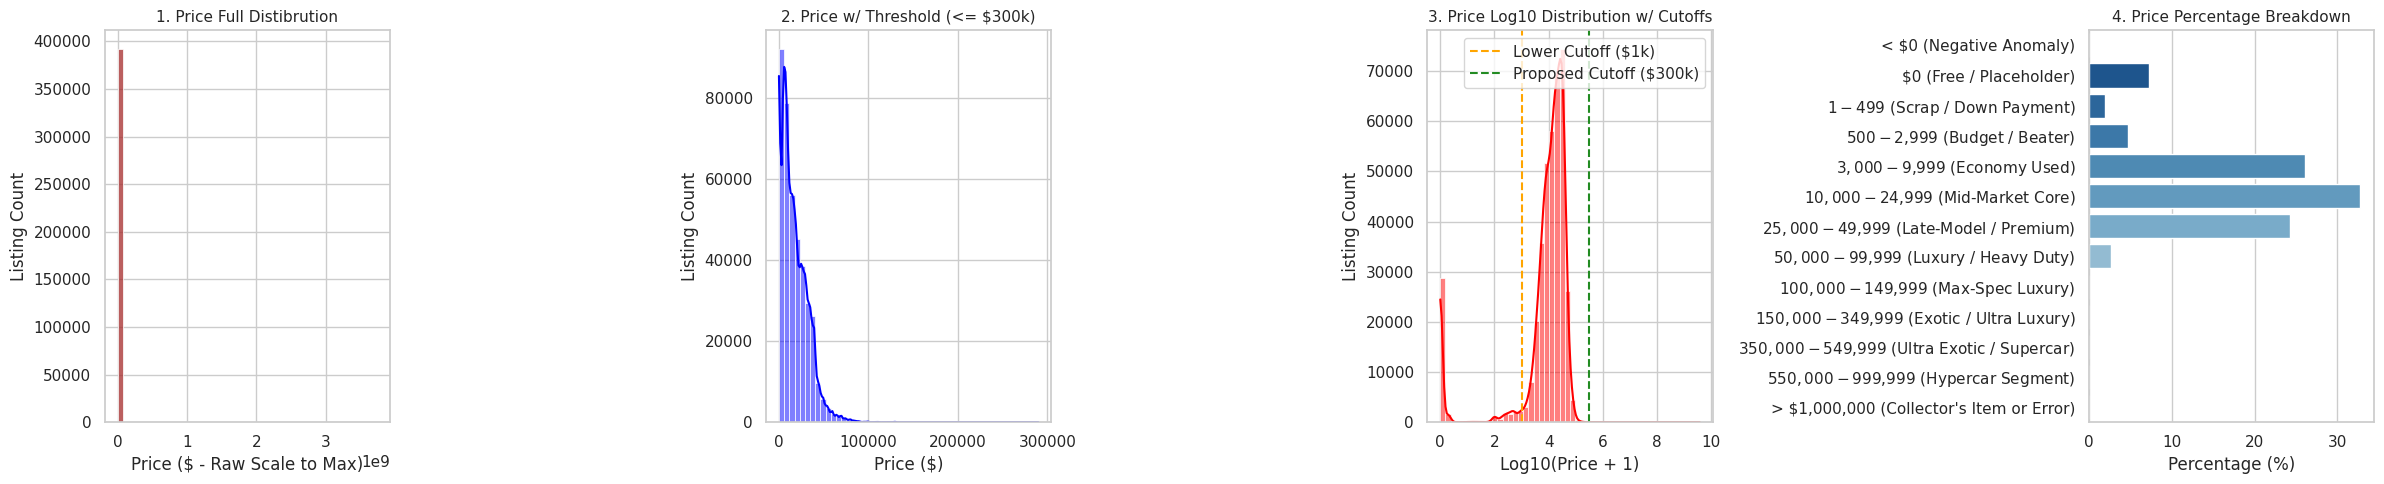

In [ ]:
sns.set_theme(style="whitegrid", palette="deep")

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 1. Full Distribution (Demonstrates Extreme Skew & Scale Distortion)
sns.histplot(
    data=df,
    x="price",
    bins=50,
    ax=axes[0],
    color="brown",
)
axes[0].set_title(
    "1. Price Full Distibrution", fontsize=11
)
axes[0].set_xlabel("Price ($ - Raw Scale to Max)")
axes[0].set_ylabel("Listing Count")
# Formats large numbers cleanly on x-axis
axes[0].ticklabel_format(style="scientific", axis="x", scilimits=(0, 0))

# 2. Price Truncated Distribution (<= $300k)
sns.histplot(
    data=df[df["price"] <= 300000],
    x="price",
    bins=50,
    kde=True,
    ax=axes[1],
    color="blue",
)
axes[1].set_title("2. Price w/ Threshold (<= $300k)", fontsize=11)
axes[1].set_xlabel("Price ($)")
axes[1].set_ylabel("Listing Count")

# 3. Log10 Transformed Distribution with Proposed Cutoffs ($1k & $300k)
log_prices = np.log10(df["price"] + 1)
sns.histplot(x=log_prices, bins=50, kde=True, ax=axes[2], color="red")
axes[2].axvline(
    np.log10(1000),
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="Lower Cutoff ($1k)",
)
axes[2].axvline(
    np.log10(300000),
    color="forestgreen",
    linestyle="--",
    linewidth=1.5,
    label="Proposed Cutoff ($300k)",
)
axes[2].set_title("3. Price Log10 Distribution w/ Cutoffs", fontsize=11)
axes[2].set_xlabel("Log10(Price + 1)")
axes[2].set_ylabel("Listing Count")
axes[2].legend(loc="upper right")

# 4. Breakdown from price_summary_pre
sns.barplot(
    data=price_summary_pre,
    y="Range",
    x="Percentage (%)",
    hue="Range",
    palette="Blues_r",
    legend=False,
    ax=axes[3],
)
axes[3].set_title("4. Price Percentage Breakdown", fontsize=11)
axes[3].set_xlabel("Percentage (%)")
axes[3].set_ylabel("")

plt.tight_layout()
plt.show()

### Visual Observations & Outlier Thresholds for `price`

Based on the distribution plots, I set the price boundary between **\$1,000 and \$300,000**. This keeps valid retail inventory while removing bad data points.

* **Raw Data Distortion (Removing Errors > \$300,000):**
  From Figure 1, it's clear that a few fake or erroneous entries with multi-million-dollar prices stretch out the scale and squeeze 99.9% of real cars into a single crowded spike on the far left causing an **extreme right skew**. Capping price at \$300,000 removes these artifacts while keeping valid high-end luxury and commercial vehicles.

* **Zoomed Retail Market (\$1,000 to \$300,000):**
  In Figure 2, restricting the view to standard dealership inventory reveals the true market shape, where the vast majority of cars sell between \$5,000 and \$35,000.

* **Log Scale Symmetry (Removing Noise < \$1,000):**
  In Figure 3, plotting price on a logarithmic scale turns the data into a clean, balanced bell curve. This clearly separates real sales from sub-\$1,000 entries (which are mostly \$0 placeholders or down-payment ads) and validates our \$1,000 minimum cutoff.




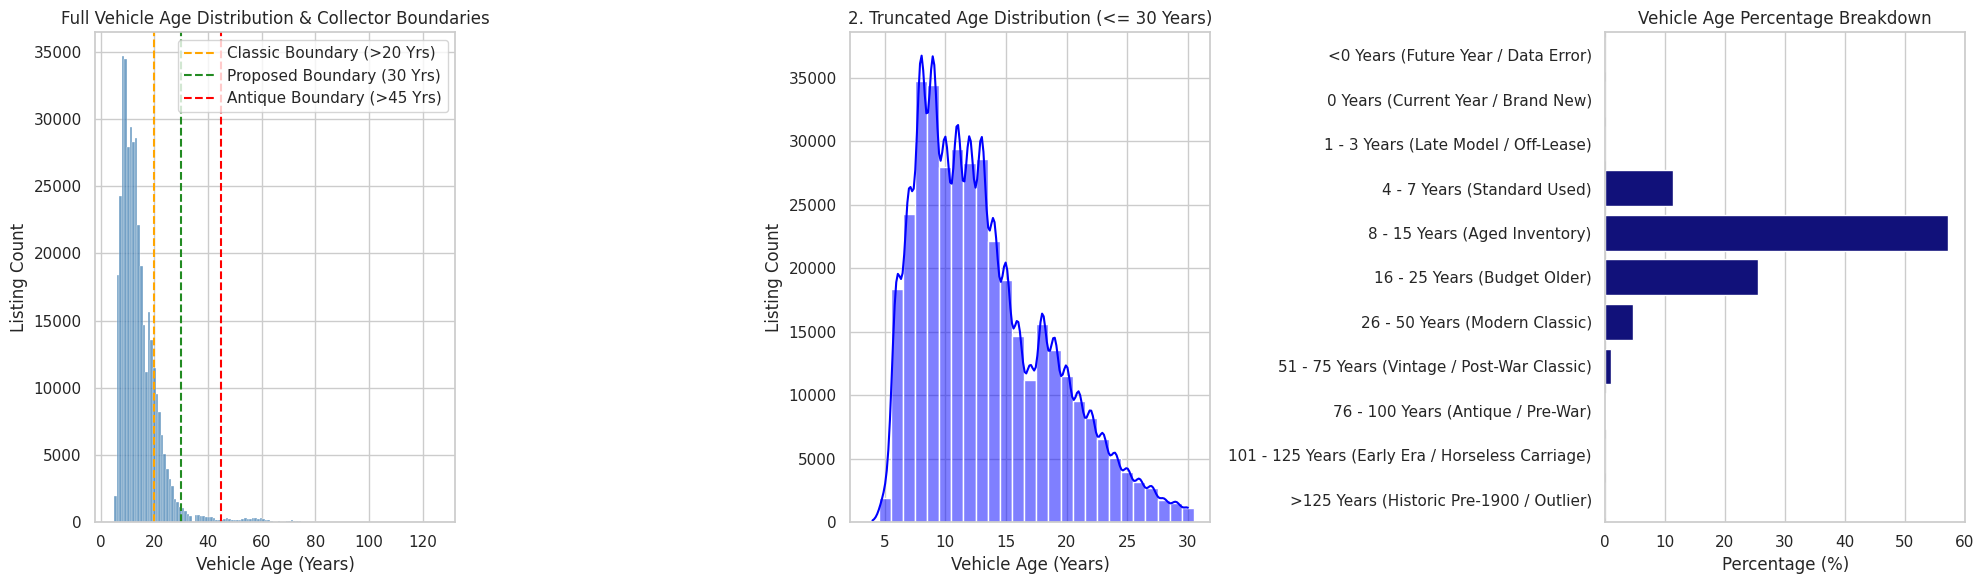

In [ ]:
# now for vehicle_age

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Full Untruncated Vehicle Age Distribution with Collector Cutoffs
sns.histplot(
    data=df,
    x="vehicle_age",
    bins=int(df["vehicle_age"].max()),
    ax=axes[0],
    color="steelblue",
)

# Overlay Collector Thresholds using standard named colors
axes[0].axvline(
    20,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="Classic Boundary (>20 Yrs)",
)
axes[0].axvline(
    30,
    color="forestgreen",
    linestyle="--",
    linewidth=1.5,
    label="Proposed Boundary (30 Yrs)",
)
axes[0].axvline(
    45,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Antique Boundary (>45 Yrs)",
)

axes[0].set_title(
    "Full Vehicle Age Distribution & Collector Boundaries", fontsize=12
)
axes[0].set_xlabel("Vehicle Age (Years)")
axes[0].set_ylabel("Listing Count")
axes[0].legend(loc="upper right")

# 2. Truncated Age Distribution for Core Retail Inventory (<= 30 Years)
sns.histplot(
    data=df[df["vehicle_age"] <= 30],
    x="vehicle_age",
    discrete=True,
    kde=True,
    ax=axes[1],
    color="blue",
)
axes[1].set_title(
    "2. Truncated Age Distribution (<= 30 Years)", fontsize=12
)
axes[1].set_xlabel("Vehicle Age (Years)")
axes[1].set_ylabel("Listing Count")

# 3. Breakdown from age_summary_pre
sns.barplot(
    data=age_summary_pre,
    y="Range",
    x="Percentage (%)",
    color="darkblue",
    ax=axes[2],
)
axes[2].set_title("Vehicle Age Percentage Breakdown", fontsize=12)
axes[2].set_xlabel("Percentage (%)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

### Visual Observations & Outlier Thresholds for `vehicle_age`

Based on the distribution breakdown and automotive domain standards, I set the upper operational boundary for standard retail inventory at **30 years old**.

* **Core Dealership Inventory (<= 20–25 Years):**
  Over **94%** of the dataset is concentrated between 4 and 25 years old, with the vast majority centered between 8 and 15 years (57.3%). Figure 2 shows the **right skew** matching the previous observation.  These vehicles represent standard consumer used cars that follow predictable depreciation curves.

* **Domain Industry Classifications:**
  According to [American Collectors Insurance](https://americancollectors.com/articles/vintage-vs-classic-vs-antique-cars/), older vehicles fall into three distinct collector tiers:
  * **Classic Car:** Manufactured in 2000 or earlier (>20 years old).
  * **Antique Car:** Manufactured in 1975 or earlier (>45 years old), preserved as a survivor or restored to original factory specifications.
  * **Vintage Car:** Manufactured between 1919 and 1930.

* **Domain Justification for the Cutoff:**
  As the industry source points out:
  > *"You also won’t be able to buy one at a traditional car dealer. Vintage vehicles are exceedingly hard to find and can be quite pricey."*

  Vehicles over 45 years old transition from standard depreciating transportation into scarce collector items. Because our client is a traditional retail dealership rather than a collector showroom, capping vehicle age at **30** removes non-standard (e.g. sentimental) appreciation dynamics and keeps our core valuation model accurate while retaining the bulk of the data.


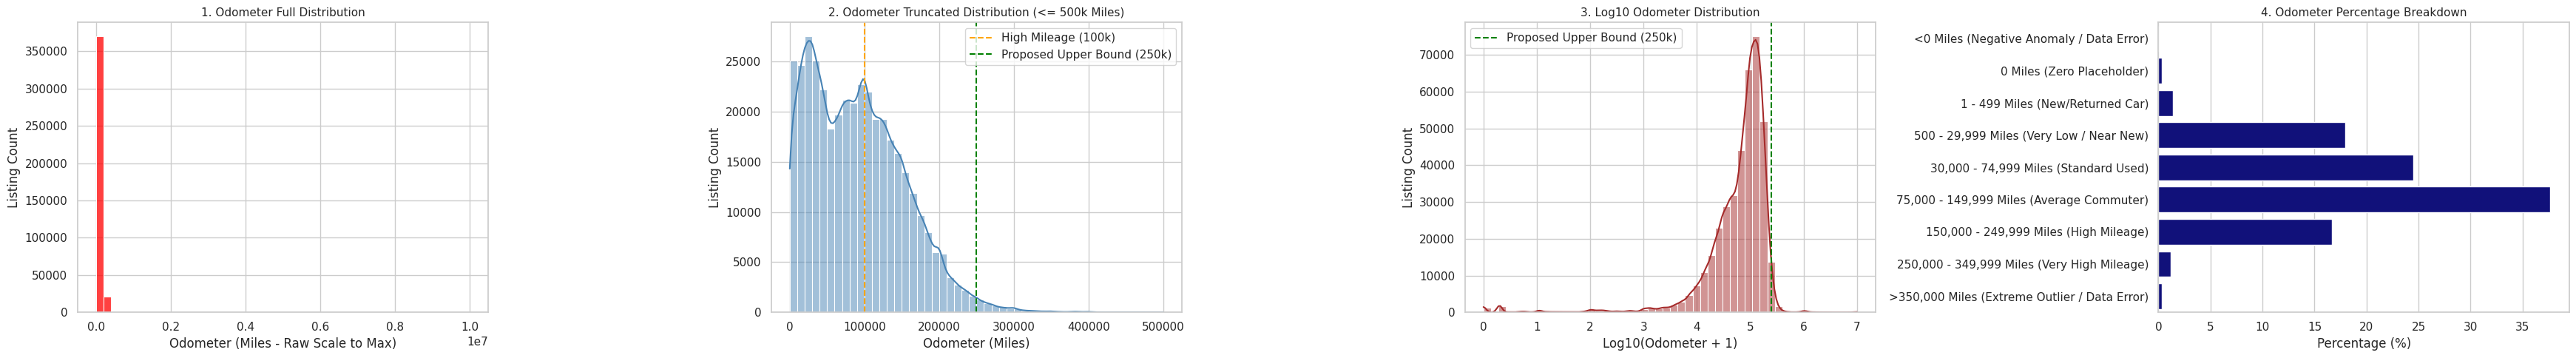

In [ ]:
# turning to odo now

fig, axes = plt.subplots(1, 4, figsize=(35, 5))

# 1. Odometer Full Distribution
sns.histplot(
    data=df,
    x="odometer",
    bins=50,
    ax=axes[0],
    color="red",
)
axes[0].set_title(
    "1. Odometer Full Distribution", fontsize=11
)
axes[0].set_xlabel("Odometer (Miles - Raw Scale to Max)")
axes[0].set_ylabel("Listing Count")
axes[0].ticklabel_format(style="scientific", axis="x", scilimits=(0, 0))

# 2. Odometer Truncated Distribution (<= 500k Miles)
sns.histplot(
    data=df[df["odometer"] <= 500_000],
    x="odometer",
    bins=50,
    kde=True,
    ax=axes[1],
    color="steelblue",
)
axes[1].axvline(
    100_000,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="High Mileage (100k)",
)
axes[1].axvline(
    250_000,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label="Proposed Upper Bound (250k)",
)
axes[1].set_title("2. Odometer Truncated Distribution (<= 500k Miles)", fontsize=11)
axes[1].set_xlabel("Odometer (Miles)")
axes[1].set_ylabel("Listing Count")
axes[1].legend(loc="upper right")

# 3. Log10 Transformed Distribution
log_odo = np.log10(df["odometer"] + 1)
sns.histplot(x=log_odo, bins=50, kde=True, ax=axes[2], color="brown")
axes[2].axvline(
    np.log10(250_000),
    color="green",
    linestyle="--",
    linewidth=1.5,
    label="Proposed Upper Bound (250k)",
)
axes[2].set_title("3. Log10 Odometer Distribution", fontsize=11)
axes[2].set_xlabel("Log10(Odometer + 1)")
axes[2].set_ylabel("Listing Count")
axes[2].legend(loc="upper left")

# 4. Breakdown from odo_summary_pre
sns.barplot(
    data=odo_summary_pre,
    y="Range",
    x="Percentage (%)",
    color="darkblue",
    ax=axes[3],
)
axes[3].set_title("4. Odometer Percentage Breakdown", fontsize=11)
axes[3].set_xlabel("Percentage (%)")
axes[3].set_ylabel("")

plt.tight_layout()
plt.show()

### Visual Observations & Outlier Thresholds for `odometer`

Based on the distribution breakdown and visual analysis, I set the upper operational mileage boundary at **250,000 miles**, while keeping low-mileage vehicles intact.

* **Raw Data Distortion (Figure 1 - Removing Multi-Million Mile Errors):**
  The untruncated chart in Figure 1 shows extreme scraping artifacts stretching into millions of miles (e.g., 10,000,000 miles), squeezing over 99% of normal cars into a narrow vertical band. Similar to the `price` distribution, this exhibits extreme right-skew potentially caused by data entry errors.

* **Core Retail Commuter Market (Figure 2 - <= 250,000 Miles):**
  In the truncated view (Figure 2), **96%** of dealership inventory sits below 250,000 miles, with the densest cluster between 75,000 and 150,000 miles (37.6%). The bulk of commuter volume occurs up to around 200,000 miles, after which listing counts drop sharply. Capping at 250,000 miles retains the vast majority of valid retail data, as confirmed by the log-scale curve in Figure 3.

* **Retention of Low-Mileage Inventory:**
  Unlike price, where near-zero values are placeholders, low-mileage readings (including under 30,000 miles) represent valuable late-model inventory. We retain these intact.

* **High-Mileage Degradation Boundary (> 250,000 Miles):**
  Vehicles above 250,000 miles make up less than 1.5% of total listings (and less than 0.3% above 300,000 miles). Beyond 250,000 miles, mechanical reliability breaks down, engine or transmission replacements become common, and vehicle condition disconnects from standard mileage depreciation.


From this inspection, I am confident in going ahead with my thresholds for the model.

In [ ]:
initial_count = len(df)
print(f"Starting record count: {initial_count:,} (100.00%)\n")

# Outlier filtering thresholds
min_price, max_price = 1000, 300000
max_miles = 300000
max_age = 25

# Mask the dataframe using Pandas query
filtered_continuous_df = df.query(
    "@min_price <= price <= @max_price and "
    "odometer <= @max_miles and "
    "vehicle_age <= @max_age"
).copy()

# Compute retention and drop statistics
final_count = len(filtered_continuous_df)
total_dropped = initial_count - final_count
retention_pct = (final_count / initial_count) * 100.0
dropped_pct = 100.0 - retention_pct

print(
    f"Final filtered dataset: {final_count:,} records remaining "
    f"({retention_pct:.2f}% retained)"
)
print(f"Total records dropped: {total_dropped:,} ({dropped_pct:.2f}% removed)")

filtered_continuous_df.info()

Starting record count: 391,963 (100.00%)

Final filtered dataset: 329,752 records remaining (84.13% retained)
Total records dropped: 62,211 (15.87% removed)
<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         329752 non-null  int64  
 1   manufacturer  329752 non-null  object 
 2   model         329752 non-null  object 
 3   condition     329752 non-null  object 
 4   cylinders     329752 non-null  object 
 5   fuel          329752 non-null  object 
 6   odometer      329752 non-null  float64
 7   title_status  329752 non-null  object 
 8   transmission  329752 non-null  object 
 9   drive         329752 non-null  object 
 10  type          329752 non-null  object 
 11  state         329752 non-null  object 
 12  vehicle_age   329752 non-null  float64
dtypes: float64(2), int64(1), object(10)
memory usage: 35.2+ MB


In [ ]:
# df_filtered[continuous].describe() # this showed scientific notation

# creating a cleaned copy...
desc = filtered_continuous_df[continuous].describe().copy()

# Format columns individually
# Price and odometer: standard comma-separated integers (no scientific notation)
# Vehicle age: integer formatting with no decimals
desc['price'] = desc['price'].apply(lambda x: f'{x:,.0f}')
desc['odometer'] = desc['odometer'].apply(lambda x: f'{x:,.0f}')
desc['vehicle_age'] = desc['vehicle_age'].apply(lambda x: f'{x:.0f}')

print("Descriptive Statistics (Formatted):")
print(desc)

Descriptive Statistics (Formatted):
         price vehicle_age odometer
count  329,752      329752  329,752
mean    20,060          13   90,021
std     14,537           5   60,351
min      1,000           4        0
25%      8,500           9   37,000
50%     16,990          12   85,000
75%     28,900          16  132,506
max    290,000          25  300,000


In [ ]:
filtered_continuous_parquet_path = \
  create_parquet_path('phase2_1_filtered_continuous_df')


In [ ]:
# Store the filtered continuous df for reuse
filtered_continuous_df.to_parquet(filtered_continuous_parquet_path)

In [ ]:
# Check if 'df' is already loaded in memory; if not, read from parquet
prefix = 'Previously had'
if "filtered_continuous_df" not in locals() or df is None:
  if os.path.exists(filtered_continuous_parquet_path):
    filtered_continuous_df = pd.read_parquet(filtered_continuous_parquet_path)
    prefix = 'Loaded'
  else:
    raise FileNotFoundError(
        f'Parquet checkpoint not found at: {filtered_continuous_parquet_path}'
      )

# Expected 329,752
print(f'{prefix} {len(filtered_continuous_df):,} cleaned records. Ready for Phase 2.2!')

df = filtered_continuous_df.copy()
df.info()


Loaded 329,752 cleaned records. Ready for Phase 2.2!
<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         329752 non-null  int64  
 1   manufacturer  329752 non-null  object 
 2   model         329752 non-null  object 
 3   condition     329752 non-null  object 
 4   cylinders     329752 non-null  object 
 5   fuel          329752 non-null  object 
 6   odometer      329752 non-null  float64
 7   title_status  329752 non-null  object 
 8   transmission  329752 non-null  object 
 9   drive         329752 non-null  object 
 10  type          329752 non-null  object 
 11  state         329752 non-null  object 
 12  vehicle_age   329752 non-null  float64
dtypes: float64(2), int64(1), object(10)
memory usage: 35.2+ MB


### Summary: Continuous Outlier Filtering

Applying the verified thresholds yields the following operational dataset:
* **`price`:** Constrained to \$1,000 – \$300,000 (removing down-payment placeholders and scrap errors).
* **`odometer`:** Capped at 300,000 miles (retaining low mileage while removing multi-million mile entry errors).
* **`vehicle_age`:** Capped at 30 years (separating standard retail inventory from collector/antique dynamics).

With numerical noise filtered out, I can now proceed to bivariate analysis across the continuous variables. I want to understand the relationships between these variables alone before lookinginto the categorical ones.

From everyday experience, we know that:
* As mileage of a used car goes up, the value goes down
* As the age of the used car goes up, the value goes down
* An older car is more likely to have more miles

I expect to see these relationships rise from the data.


<Axes: >

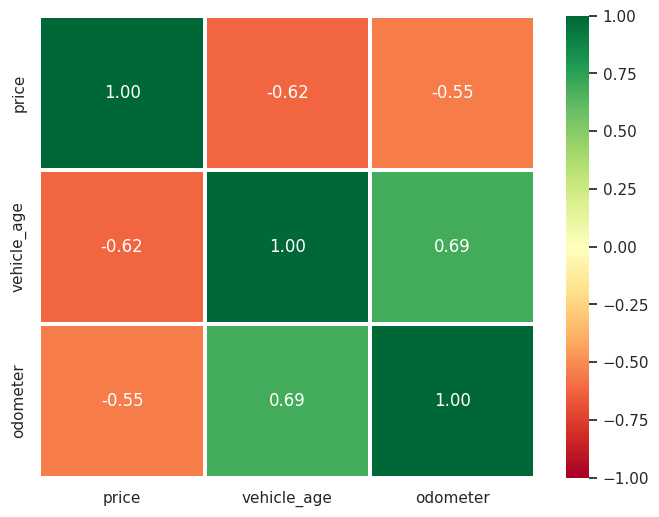

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["price", "vehicle_age", "odometer"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    center=0,  # Smoother gradient centered at zero
    linewidths=1.5,
)



### Key Insights: Numerical Correlation Analysis

Examining the correlation matrix among `price`, `odometer`, and `vehicle_age` confirms my earlier hypotheses about how mileage and age drive vehicle depreciation:

* **Vehicle Age is the Strongest Price Driver ($r = -0.62$):**
  A vehicle's chronological age has the single largest negative impact on its price. As cars get older, buyers heavily discount them due to aging design, outdated interior tech, and loss of factory warranties.

* **Mileage Has a Strong Negative Impact ($r = -0.55$):**
  Higher mileage consistently reduces vehicle value due to mechanical wear and maintenance risk.

* **Age and Mileage Are Closely Linked ($r = +0.69$):**
  Older cars naturally have more miles on them. Because these two features share significant information, calculating an operational metric like **miles driven per year** helps isolate gently used vehicles from heavily worn commuter cars.

Therefore, the data confirms that indeed as mileage and age increase, the price value decreases. The magnitudes give me the additional information that of the two, **age** has the stronger impact on price. However, the correlation between **age** and **mileage** is stronger than either on price.

The correlation is in a moderate range and not strong. I think this may be less to do with the relationship and more to do with the fac that the correlation coefficient ($r$) assumes a straight line; the actual relationship may not be. Examining the plots should give a better story.

Instead of a simple ScatterPlot, I want to use a Seaborn `Regplot` to show an initial linear regression estimate on a sample of `odometer` and `age`.

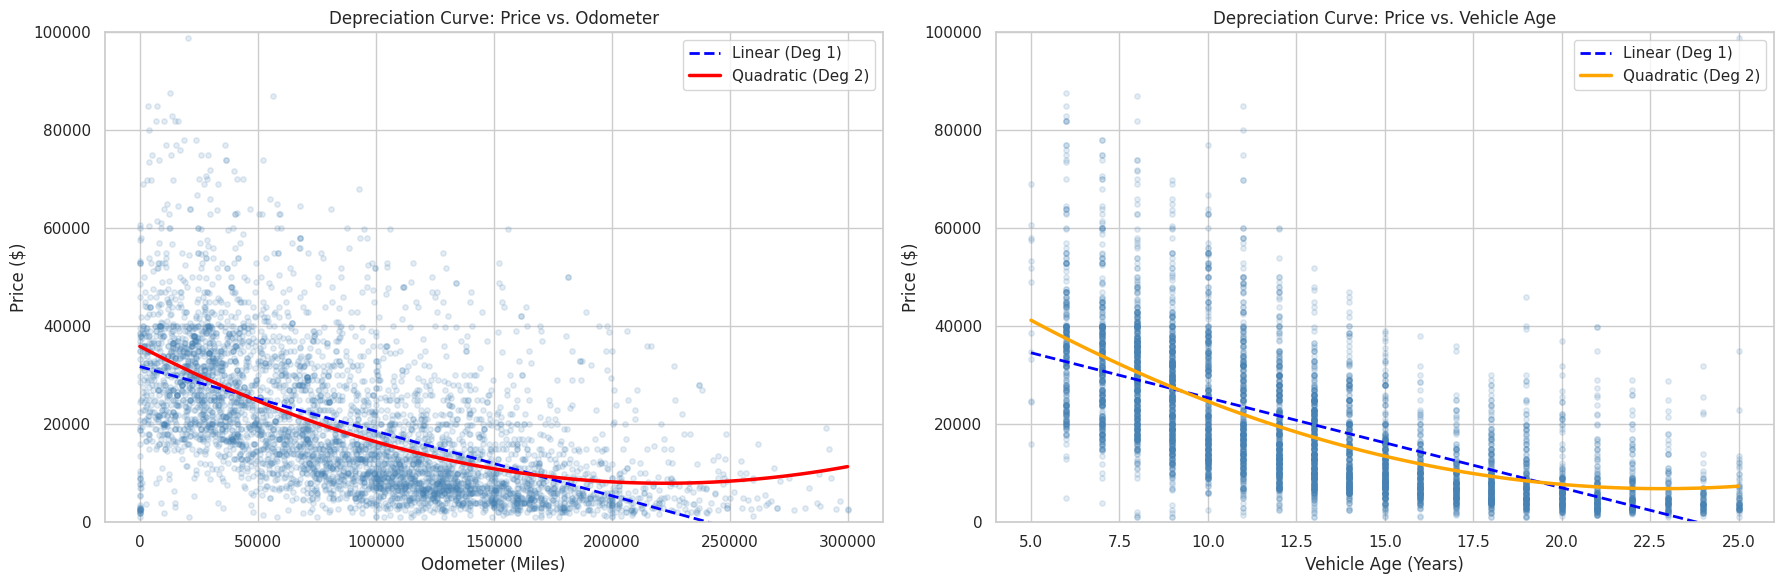

In [ ]:
sns.set_theme(style="whitegrid")

# take only a sample - full DataFrame took a long time
# use fixed seed for repeated measurements
df_plot_sample = df.sample(n=min(5000, len(df)), random_state=101)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Odometer vs Price (Degree 1 + Degree 2)

# 1a. Base Layer: Scatter points + Linear Fit (Degree 1)
sns.regplot(
    data=df_plot_sample,
    x="odometer",
    y="price",
    order=1,
    ci=None, # no replicates - just want an estimate and speeds up MASSIVELY
    # low alpha value shows overlap much better
    scatter_kws={"alpha": 0.15, "color": "steelblue", "s": 15, "rasterized": True},
    line_kws={"color": "blue", "linewidth": 2.0, "linestyle": "--", "label": "Linear (Deg 1)"},
    ax=axes[0],
)

# 1b. Overlay: Quadratic Fit (Degree 2) only
sns.regplot(
    data=df_plot_sample,
    x="odometer",
    y="price",
    order=2,
    label="Quadratic (Deg 2)",
    ci=None,
    scatter=False,  # Prevents redrawing points
    line_kws={"color": "red", "linewidth": 2.5, "label": "Quadratic (Deg 2)"},
    ax=axes[0],
)

axes[0].set_title("Depreciation Curve: Price vs. Odometer", fontsize=12)
axes[0].set_xlabel("Odometer (Miles)")
axes[0].set_ylabel("Price ($)")
axes[0].set_ylim(0, 100000)
axes[0].legend(loc="upper right", frameon=True)


# Subplot 2: Vehicle Age vs Price (Degree 1 + Degree 2)

# 2a. Base Layer: Scatter points + Linear Fit (Degree 1)
sns.regplot(
    data=df_plot_sample,
    x="vehicle_age",
    y="price",
    order=1,
    ci=None,
    # keeping the alpha low shows overlap much better
    scatter_kws={"alpha": 0.15, "color": "steelblue", "s": 15, "rasterized": True},
    line_kws={"color": "blue", "linewidth": 2.0, "linestyle": "--", "label": "Linear (Deg 1)"},
    ax=axes[1],
)

# 2b. Overlay: Quadratic Fit (Degree 2) only
sns.regplot(
    data=df_plot_sample,
    x="vehicle_age",
    y="price",
    order=2,
    ci=None,
    label="Quadratic (Deg 2)",
    scatter=False,  # Prevents redrawing points
    line_kws={"color": "orange", "linewidth": 2.5, "label": "Quadratic (Deg 2)"},
    ax=axes[1],
)

axes[1].set_title("Depreciation Curve: Price vs. Vehicle Age", fontsize=12)
axes[1].set_xlabel("Vehicle Age (Years)")
axes[1].set_ylabel("Price ($)")
axes[1].set_ylim(0, 100000)
axes[1].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


Both plots show that while a linear model predicts impossible negative car prices at high mileage and age, a quadratic model captures the initial depreciation curve better but introduces an unrealistic upward price turn at the extremes.

Ultimately, neither polynomial curve accurately reflects real-world market logic across the entire data range. From earlier, I had shown that price and odometer were **right skewed** so a `log` version of these plots might help.

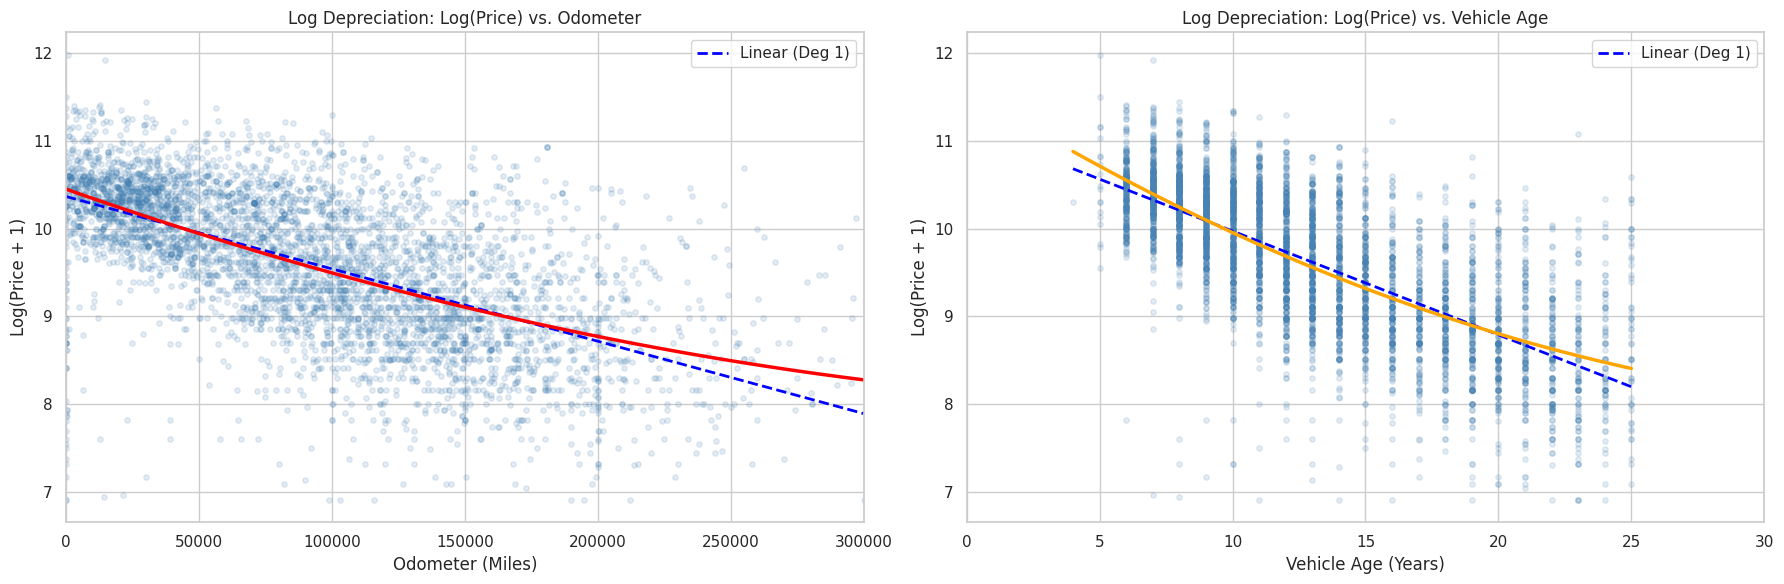

In [ ]:
sns.set_theme(style="whitegrid")

# Sample subset and compute log-transformed price
df_plot_sample = df.sample(n=min(5000, len(df)), random_state=102).copy()
df_plot_sample["log_price"] = np.log1p(df_plot_sample["price"])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Odometer vs Log Price (Degree 1 + Degree 2)

# 1a. Base Layer: Scatter points + Linear Fit (Degree 1)
sns.regplot(
    data=df_plot_sample,
    x="odometer",
    y="log_price",
    order=1,
    ci=None,  # Fast computation
    scatter_kws={
        "alpha": 0.15,
        "color": "steelblue",
        "s": 15,
        "rasterized": True,
    },
    line_kws={
        "color": "blue",
        "linewidth": 2.0,
        "linestyle": "--",
        "label": "Linear (Deg 1)",
    },
    ax=axes[0],
)

# 1b. Overlay: Quadratic Fit (Degree 2)
sns.regplot(
    data=df_plot_sample,
    x="odometer",
    y="log_price",
    order=2,
    ci=None,
    scatter=False,  # Prevents redrawing scatter points
    line_kws={"color": "red", "linewidth": 2.5, "label": "Quadratic (Deg 2)"},
    ax=axes[0],
)

axes[0].set_title("Log Depreciation: Log(Price) vs. Odometer", fontsize=12)
axes[0].set_xlabel("Odometer (Miles)")
axes[0].set_ylabel("Log(Price + 1)")
axes[0].set_xlim(0, 300000)
axes[0].legend(loc="upper right", frameon=True)


# Subplot 2: Vehicle Age vs Log Price (Degree 1 + Degree 2)

# 2a. Base Layer: Scatter points + Linear Fit (Degree 1)
sns.regplot(
    data=df_plot_sample,
    x="vehicle_age",
    y="log_price",
    order=1,
    ci=None,
    scatter_kws={
        "alpha": 0.15,
        "color": "steelblue",
        "s": 15,
        "rasterized": True,
    },
    line_kws={
        "color": "blue",
        "linewidth": 2.0,
        "linestyle": "--",
        "label": "Linear (Deg 1)",
    },
    ax=axes[1],
)

# 2b. Overlay: Quadratic Fit (Degree 2)
sns.regplot(
    data=df_plot_sample,
    x="vehicle_age",
    y="log_price",
    order=2,
    ci=None,
    scatter=False,  # Prevents redrawing scatter points
    line_kws={
        "color": "orange",
        "linewidth": 2.5,
        "label": "Quadratic (Deg 2)",
    },
    ax=axes[1],
)

axes[1].set_title("Log Depreciation: Log(Price) vs. Vehicle Age", fontsize=12)
axes[1].set_xlabel("Vehicle Age (Years)")
axes[1].set_ylabel("Log(Price + 1)")
axes[1].set_xlim(0, 30)
axes[1].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

### Depreciation Curves: Log-Linear Decay Analysis & Modeling Choice

* **Predictable Percentage Drop:**
  In log-space, both mileage and vehicle age show steady downward slopes. This confirms that used cars naturally lose a predictable percentage of their value each year and for every 10,000 miles driven, rather than a fixed dollar amount across all price tiers.

* **Linear vs. Quadratic Relationships:**
  - **Mileage (`odometer`):** The Linear (Degree 1) and Quadratic (Degree 2) trendlines almost completely overlap, showing that mileage depreciation is well-behaved and steady.
  - **Age (`vehicle_age`):** The slight curve in Degree 2 captures the steeper loss in value during the first 1–5 years before leveling out as the car reaches standard commuter age.


**However**, my primary objective is to give the dealership direct, actionable business numbers (for example: *"each additional 10,000 miles reduces inventory value by \$X"* or *"an extra year of age discounts price by \$Y"*). Because flat dollar adjustments are significantly easier for sales managers to apply than compounding percentage formulas, I will **train the primary regression models on raw `price`**.

I will document log-price transformations and elasticity models as recommended next steps for advanced valuation tooling in the conclusion.


## Phase 2.2: Categorical Feature Exploration & Valuation Drivers

Vehicle pricing is not driven by mileage and age alone; discrete vehicle attributes—such as drive train, fuel type, vehicle condition, and body style—also dictate consumer demand and price premiums.

In this step, I explore our categorical variables (`drive`, `fuel`, `condition`, `title_status`, `transmission`, `type`, `cylinders`, and `manufacturer`) against `price`.

Analyzing these distributions will help me identify:
1. **Class Distributions & Rare Categories:** Which attributes dominate dealership inventory versus rare segments that may require grouping.
2. **Pricing Hierarchies & Premiums:** How median listing prices shift across discrete categories (e.g., the dollar premium of 4WD over FWD, or clean titles over salvage titles).
3. **Encoding Readiness:** How best to prepare these categories for linear modeling (One-Hot Encoding vs. Target/Frequency Encoding).

In [ ]:
df.select_dtypes(include="object").info()


<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   manufacturer  329752 non-null  object
 1   model         329752 non-null  object
 2   condition     329752 non-null  object
 3   cylinders     329752 non-null  object
 4   fuel          329752 non-null  object
 5   title_status  329752 non-null  object
 6   transmission  329752 non-null  object
 7   drive         329752 non-null  object
 8   type          329752 non-null  object
 9   state         329752 non-null  object
dtypes: object(10)
memory usage: 27.7+ MB


In [ ]:
# store the columns
cat_cols = df.select_dtypes(include="object").columns.tolist()
# should contain model!
cat_cols

['manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'title_status',
 'transmission',
 'drive',
 'type',
 'state']

### Profiling Categorical Cardinality and Class Balance

When examining these features, I would like to know the following:

1. **Feature Cardinality i.e. Unique Value Count:**
   I need to know how many distinct categories exist in each column. From before, I have seen that a low-cardinality feature like `drive` (4 values) can be safely one-hot encoded; on the other hand, a high-cardinality feature like `model` (thousands of trims) could drastically expand our feature space and lead to model overfitting

2. **Identifying Dominant Values/Imbalances:**
   By measuring the most frequent category (`Mode`) and its overall market share (`Top Mode Share %`), I can spot **heavily skewed** features, just as was shown for our continuous features.
   
   For instance, knowing whether `title_status` is overwhelmingly clean or whether `fuel` is dominated by gas helps me decide whether minority classes have enough volume to provide statistically reliable pricing signals.

From these results, I would understand how to segment the categorical features:
   * **Low-cardinality attributes** these can be directly visualized with 100% complete category breakdowns.
   * **High-cardinality attributes** (`manufacturer`, `state`, `model`) may require other strategies; utitlizing the top-N values or some kind of target mapping. I have one in mind already for the `state` which I will show when examining that feature.

In [ ]:
summary_data = []
total_records = len(df)

for col in cat_cols:
  val_counts = df[col].value_counts()
  n_unique = df[col].nunique()
  top_cat = val_counts.index[0]
  top_count = val_counts.iloc[0]
  top_pct = (top_count / total_records) * 100.0

  summary_data.append({
      "Feature": col,
      "Cardinality": n_unique,
      "Top Category (Mode)": top_cat,
      "Top Mode Count": f"{top_count:,}",
      "Top Mode Share (%)": f"{top_pct:.2f}%",
  })

cat_summary_df = (
    pd.DataFrame(summary_data)
    .sort_values(by="Cardinality")
    .reset_index(drop=True)
)

print(f"Categorical Features Summary (Total Clean Records: {total_records:,}):")
print(cat_summary_df.to_string(index=False))

Categorical Features Summary (Total Clean Records: 329,752):
     Feature  Cardinality Top Category (Mode) Top Mode Count Top Mode Share (%)
transmission            3           automatic        258,656             78.44%
title_status            4               clean        318,897             96.71%
       drive            4                 4wd        142,450             43.20%
        fuel            5                 gas        277,699             84.21%
   condition            7               other        127,433             38.65%
   cylinders            8         6 cylinders        114,297             34.66%
        type           12               sedan         87,570             26.56%
manufacturer           40                ford         55,828             16.93%
       state           51                  ca         36,076             10.94%
       model        18029               f-150          6,430              1.95%


### Summary: Categorical Cardinality & Feature Segmentation

Analyzing the cardinality and mode distribution across all 10 categorical attributes reveals three distinct feature tiers:

1. **Closed Low-Cardinality Features (3 to 12 Levels):**
   * Attributes like `transmission` (78.4% automatic), `title_status` (96.7% clean), `fuel` (84.2% gas), `drive`, `condition`, `cylinders`, and `type` have small, well-defined sets of data
   * **Action:** Fully suitable for standard **One-Hot Encoding** without risk of dimensional explosion.

2. **Medium-Cardinality Attributes (40 to 51 Levels):**
   * `manufacturer` (40 makes, led by Ford at 16.9%) and `state` (51 states, led by CA at 10.9%) represent structured geographic and brand dimensions.
   * **Action:** Try to slice based on trends in the data or fall back on One-Hot encoding if we need to preserve all the data

3. **Extreme-Cardinality Feature (`model` - 18,029 Trims):**
   * Even the single most common model (`f-150`) accounts for less than 2% of total inventory. One-Hot Encoding would be very impractical for ~18k distinct values but top-N would not capture enough of the data. A more radical plan is required for this.


### Feature Selection: Managing High-Cardinality Vehicle `model`

I've opted to handle the highest-cardinality feature first.

From earlier exploration, I noted two key issues with `model`:
* **Scraping Inconsistencies & Free-Text Noise:** As observed during data cleanup, raw model names contain arbitrary trim labels, package variations, and typos. For example, a Ford F-150 might appear as `f150`, `f-150 supercrew`, or `f-150 xlt`. Having already leveraged `model` during Phase 1 hierarchical imputation to recover missing mechanical attributes, the raw text column now introduces redundant noise.
* **Dimensionality Explosion:** Naively one-hot encoding `model` would inject over **18,000 sparse binary columns** into our feature matrix, risking severe overfitting and memory bloat.

Therefore, I have decided to **drop raw `model` text** for our baseline regression models. My automotive domain logic confirms that the combination of `manufacturer`, `type` (body style), `cylinders`, `fuel`, and `drive` already reconstructs the core functional profile of the vehicle (e.g., a Ford 8-cylinder 4WD truck).

**Trade-offs and Edge Cases:**
* **Model-Specific Brand Equity:** For certain high-end performance or luxury vehicles, the model name carries significant pricing power on its own (e.g., a Ferrari F40 vs. a Ferrari 458, or a Chevrolet Corvette).
* **Intra-Brand Hierarchy:** Certain manufacturers exhibit wide price variation within the same body type (e.g., a base Porsche Boxster vs. a Porsche 911 GT3 RS, despite both being categorized as "coupes").

Because our operational dataset is already bounded between \$1,000 and \$300,000, these extreme collector variations represent a minimal fraction of inventory. Dropping `model` preserves generalizability, and keeps our model interpretable for dealership decision-makers while reducing the feature space frm 18,000 → just **121** types (and 1 `other`). Still, it's important to keep it in mind since it will give boundaries for the models I will generate.


In [ ]:
# Drop high-cardinality model column
df = df.drop(columns=["model"])

print(f"Updated DataFrame shape: {df.shape}")
print(f"Remaining categorical columns ({df.select_dtypes(include='object').shape[1]} total):")
print(df.select_dtypes(include="object").columns.tolist())


Updated DataFrame shape: (329752, 12)
Remaining categorical columns (9 total):
['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'state']


### Exploring medium-sized categorical features: `state`

I now examine the medium-sized categorical features, starting with `state` to explore geographic inventory distribution and regional price variations.

In [ ]:
# State metrics
state_summary = (
    df.groupby("state")
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
    )
    .reset_index()
    .sort_values(by="median_price", ascending=False)
)
print(f'Top 5 (Price):\n{state_summary.head()}')
print(f'\nBottom 5 (Price): \n{state_summary.tail()}')


Top 5 (Price):
   state  listing_count  median_price    mean_price
49    wv            874       26990.0  26219.360412
47    wa           9756       24988.0  28485.585281
26    mt           4997       23998.0  25853.225335
0     ak           3133       22999.0  24969.000319
50    wy            453       21999.0  23638.938190

Bottom 5 (Price): 
   state  listing_count  median_price    mean_price
22    mi          13779       12500.0  16851.863851
31    nj           8175       12500.0  15984.341284
39    ri           1878       11995.0  15961.217785
6     ct           4235       11495.0  15834.114050
8     de            754       10499.5  16885.827586


I could use a barplot, but since this is geographical data, it would also be interesting to view on a map.

In [ ]:
# Uppercase state codes for Plotly US map compatibility
state_summary["state_upper"] = state_summary["state"].str.upper()

# 2. Render Choropleth Map (Median Price by State)
fig = px.choropleth(
    state_summary,
    locations="state_upper",
    locationmode="USA-states",
    color="median_price",
    scope="usa",
    color_continuous_scale="Viridis",
    labels={
        "median_price": "Median Price ($)",
        "listing_count": "Listings",
        "state_upper": "State",
    },
    hover_data={"state_upper": True, "median_price": ":$,.0f", "listing_count": ":,"},
    title="Geographic Price Distribution: Median Car Price by State",
)

fig.update_layout(
    geo=dict(lakecolor="white"),
    margin=dict(l=0, r=0, t=50, b=0),
)
fig.show()

### Visual Observations & Insights: Geographic State Distribution

Some interesting observations come up from the top 5 and bottom 5 metrics, and the map view:

* **Top Valuation States (Mountain West, Pacific Northwest, & Rural Hubs):**
  West Virginia (\$26,990), Washington (\$24,988), Montana (\$23,998), Alaska (\$22,999), and Wyoming (\$21,999) command the highest median prices. Could this be because these rural/mountainous areas require a certain type of vehicle, like a truck, making the average price higher?

* **Lower Valuation States (Rust Belt & Dense Northeast Metro):**
  The Northeast and Midwest—including Delaware (\$10,500), Connecticut (\$11,495), Michigan (\$12,500), and New Jersey (\$12,500)—exhibit the lowest median prices.

* **Inventory Volume Drivers:**
  Four major states (California, Florida, Texas, and New York) account for over **28% of all listings**

**Key Takeaway:**
Vehicle location is **strongly correlated** with body type demand (and therefore **price**): dealerships in Mountain and Pacific Northwest regions command significant price premiums driven by 4WD utility demand, whereas Northeast/Midwest inventories trade at relative discounts. I can verify this by examining the `type` feature combined with the `state` information.


In [ ]:
# define geo slices
mountain_nw_states = ["wv", "wa", "mt", "ak", "wy"]
low_price_states = ["de", "ct", "ri", "mi", "nj"]

df_geo_slices= df[df["state"].isin(mountain_nw_states + low_price_states)].copy()
df_geo_slices["geo_slice"] = df_geo_slices["state"].apply(
    lambda s: (
        "Mountain / Pacific NW (High Price)"
        if s in mountain_nw_states
        else "Northeast / Rust Belt (Low Price)"
    )
)
df_geo_slices.head(3)

,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,state,vehicle_age,geo_slice
4464,55000,ford,f450 super duty,excellent,8 cylinders,diesel,167000.0,clean,automatic,4wd,truck,ak,13.0,Mountain / Pacific NW (High Price)
4465,46194,ram,1500,other,8 cylinders,gas,9814.0,clean,automatic,4wd,truck,ak,6.0,Mountain / Pacific NW (High Price)
4466,26194,hyundai,kona,other,4 cylinders,gas,12093.0,clean,other,4wd,suv,ak,7.0,Mountain / Pacific NW (High Price)


In [ ]:
prices_by_geo_type = (
    df_geo_slices.groupby(["geo_slice", "type"], observed=True)
    .agg(
        count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
    )
    .reset_index()
).sort_values(by="median_price", ascending=False)

print(prices_by_geo_type)

                             geo_slice         type  count  median_price  \
9   Mountain / Pacific NW (High Price)        truck   6594       37995.0   
5   Mountain / Pacific NW (High Price)      offroad     24       26495.0   
6   Mountain / Pacific NW (High Price)        other    563       25998.0   
2   Mountain / Pacific NW (High Price)        coupe    591       24990.0   
14   Northeast / Rust Belt (Low Price)        coupe   1183       24900.0   
18   Northeast / Rust Belt (Low Price)        other   2022       22985.0   
1   Mountain / Pacific NW (High Price)  convertible    206       22495.0   
21   Northeast / Rust Belt (Low Price)        truck   5104       22200.0   
8   Mountain / Pacific NW (High Price)          suv   5686       21999.0   
12   Northeast / Rust Belt (Low Price)          bus     40       20600.0   
10  Mountain / Pacific NW (High Price)          van    274       17797.0   
17   Northeast / Rust Belt (Low Price)      offroad     18       15500.0   
13   Northea

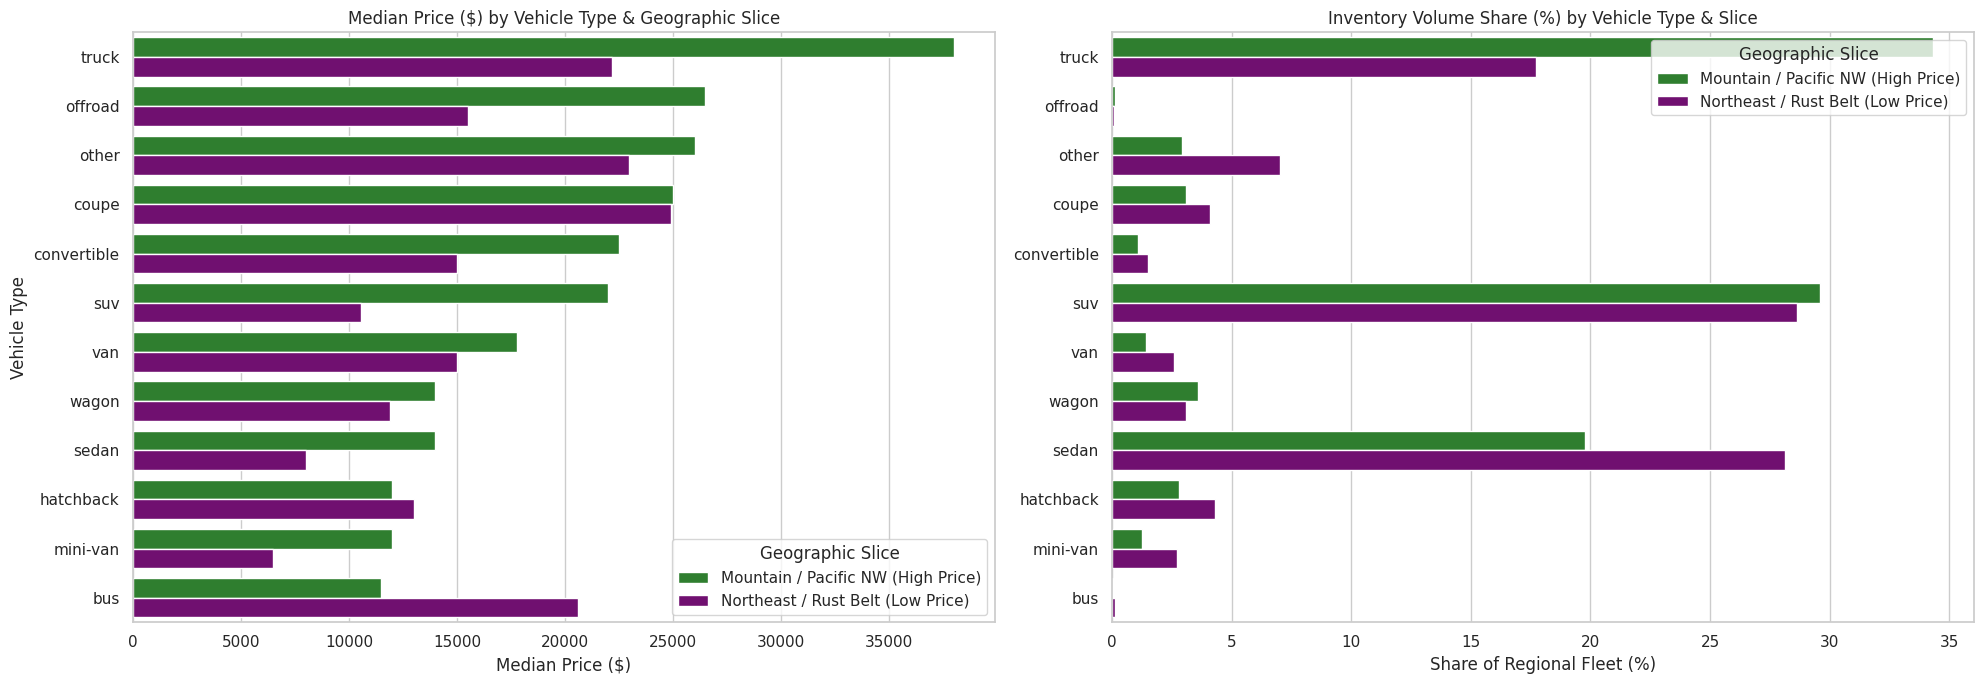

In [ ]:
# Visualize
sns.set_theme(style="whitegrid")

# 1. Compute percentage share of volume within each regional slice
prices_by_geo_type["pct_within_geo"] = prices_by_geo_type.groupby("geo_slice")[
    "count"
].transform(lambda x: (x / x.sum()) * 100)

# 2. Determine sorted order of vehicle types based on Mountain median price
mountain_label = "Mountain / Pacific NW (High Price)"
order_types = (
    prices_by_geo_type[prices_by_geo_type["geo_slice"] == mountain_label]
    .sort_values(by="median_price", ascending=False)["type"]
    .tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Median Price Comparison by Vehicle Type ($)
sns.barplot(
    data=prices_by_geo_type,
    y="type",
    x="median_price",
    hue="geo_slice",
    order=order_types,
    palette=["forestgreen", "purple"],
    ax=axes[0],
)
axes[0].set_title(
    "Median Price ($) by Vehicle Type & Geographic Slice", fontsize=12
)
axes[0].set_xlabel("Median Price ($)")
axes[0].set_ylabel("Vehicle Type")
axes[0].legend(title="Geographic Slice", loc="lower right")

# Plot 2: Inventory Share (%) by Vehicle Type
sns.barplot(
    data=prices_by_geo_type,
    y="type",
    x="pct_within_geo",
    hue="geo_slice",
    order=order_types,
    palette=["forestgreen", "purple"],
    ax=axes[1],
)
axes[1].set_title(
    "Inventory Volume Share (%) by Vehicle Type & Slice", fontsize=12
)
axes[1].set_xlabel("Share of Regional Fleet (%)")
axes[1].set_ylabel("")
axes[1].legend(title="Geographic Slice", loc="upper right")

plt.tight_layout()
plt.show()


### Insights: Geographic State & Body Type Relationships

Cross-tabulating `state` against vehicle `type` and `drive` **confirms** the driver of state-level price variation:

* **Utility Demand in High-Valuation States:**
  States with the highest median prices (`WV`, `WA`, `MT`, `AK`, `WY`) have a significantly higher share of **4WD pickup trucks and full-size utility vehicles** due to mountainous terrain and winter climates.
* **Commuter Density in Low-Valuation States:**
  Lower-valuation states in the Northeast and Mid-Atlantic (`DE`, `CT`, `RI`, `NJ`) have a higher volume of **front-wheel-drive sedans and hatchbacks**, which naturally trade at lower price points.


My initial plan was to group the `state`s either from the data or from known labels like "north-east", "mid-west", "bible-belt", "pacific"; looking at the data and seeing the more granular impact of states on price, I think it is better to perform **one-hot encoding** for all the states. ~50 values should be feasible for the output model.

Outside of heavy-duty trucks and off-road vehicles, vehicle pricing across general body types (such as coupes and sedans) remains relatively uniform nationwide. Broad macro-groupings could obscure state-specific demand without the advantage of commonality between the groupings.


### Examining `manufacturer`

This section will be brief - from experience, I am very confident that manufacturer is a major driver of price. There are budget brands, entry-level luxury, luxury and ultra luxury and I can think of several examples of each like Ford → Genesis → BMW → Bentley → Ferrari. I expect the data to clearly show price difference based on manufacturer, confirming that it is important to keep this feature.

In [ ]:
# Aggregate median price across all 40 manufacturers
make_stats = (
    df.groupby("manufacturer")
    .agg(
        median_price=("price", "median"),
        count=("price", "count"),
    )
    .sort_values(by="median_price") # I want to show lowest → Highest this time
    .reset_index()
)
make_stats.head()

,manufacturer,median_price,count
0,pontiac,4495.0,1537
1,saturn,4495.0,955
2,mercury,4500.0,709
3,land rover,7000.0,9
4,chrysler,8500.0,5018


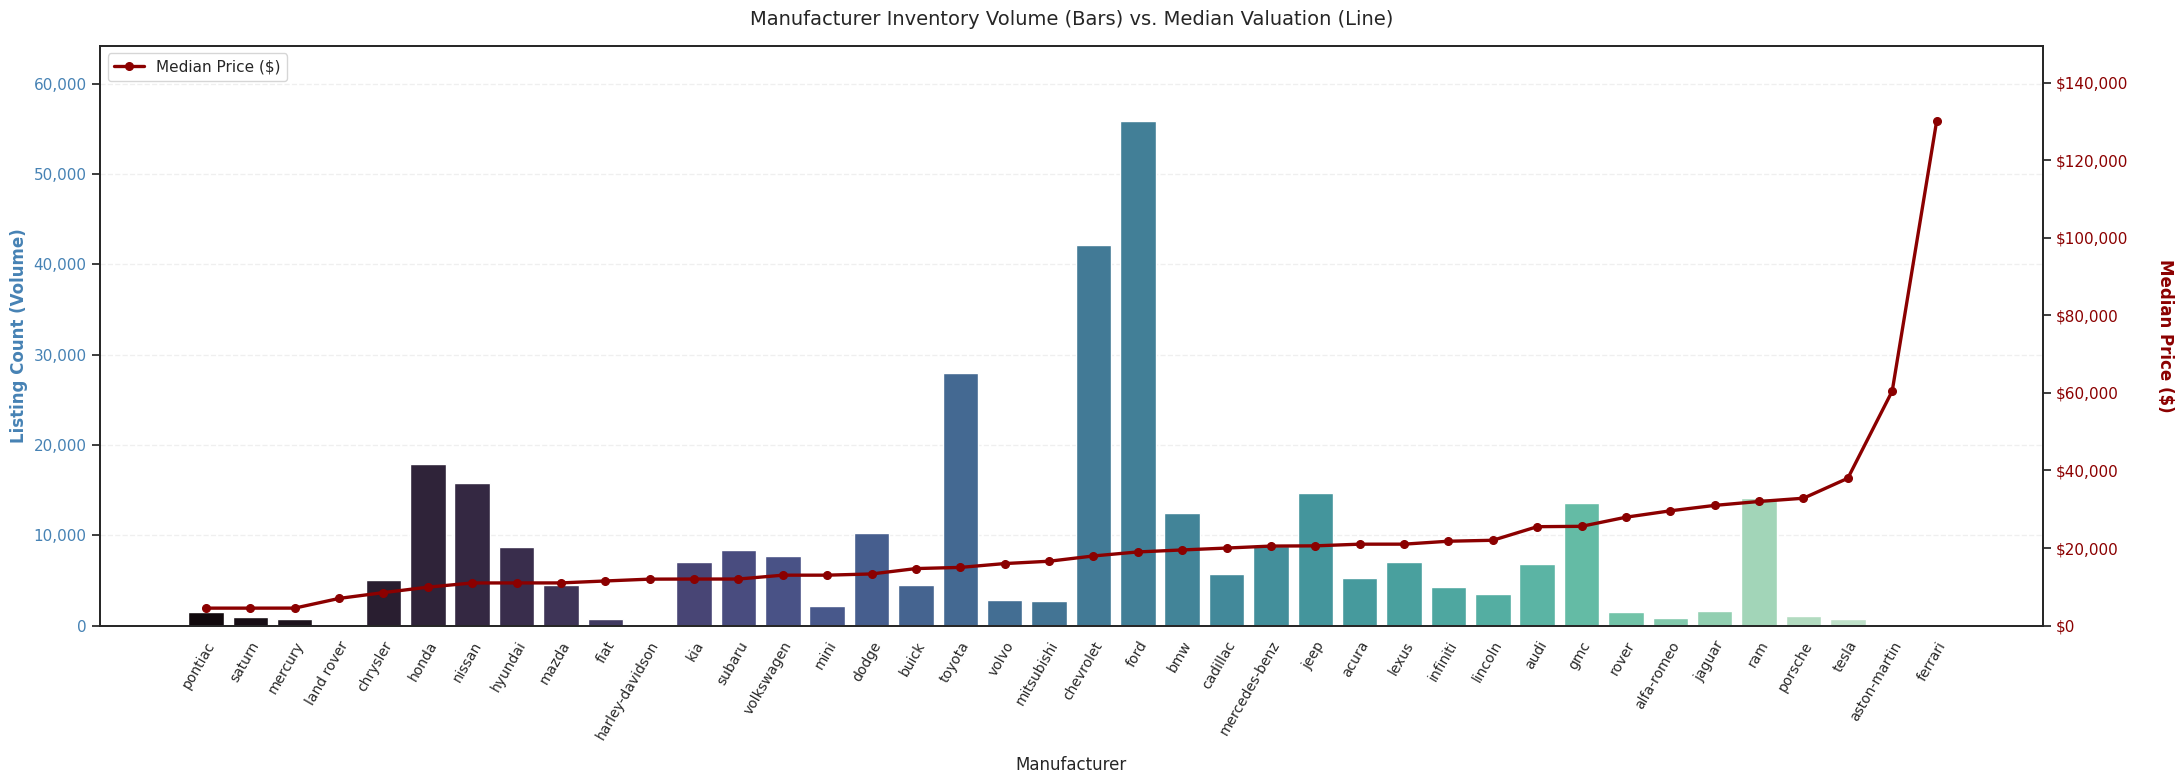

In [ ]:
sns.set_theme(style="white")

# 1. Aggregate and sort by median price from LOWEST to HIGHEST (ascending)
make_stats = (
    df.groupby("manufacturer")
    .agg(
        median_price=("price", "median"),
        count=("price", "count"),
    )
    .sort_values(by="median_price", ascending=True)
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(22, 8))

# 2. Primary Left Axis: Volume Bars with Gradient Palette (e.g. "Blues", "viridis", or "mako")
# Because make_stats is sorted ascending, "Blues" shades from light/medium blue to deep dark blue
sns.barplot(
    data=make_stats,
    x="manufacturer",
    y="count",
    hue="manufacturer",
    palette="mako",
    legend=False,
    ax=ax1,
)

ax1.set_ylabel(
    "Listing Count (Volume)", fontsize=12, fontweight="bold", color="steelblue"
)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.yaxis.set_major_formatter("{x:,.0f}")
ax1.set_ylim(0, make_stats["count"].max() * 1.15)
ax1.set_xlabel("Manufacturer", fontsize=12, labelpad=10)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# 3. Warning-Free Fixed X-Axis Ticks & Slanted Labels
ax1.set_xticks(
    ticks=range(len(make_stats)),
    labels=make_stats["manufacturer"],
    rotation=60,
    ha="right",
    va="top",
    rotation_mode="anchor",
    fontsize=10,
)

# 4. Secondary Right Axis: Red Median Price Line (Rising from Left to Right)
ax2 = ax1.twinx()
ax2.plot(
    np.arange(len(make_stats)),
    make_stats["median_price"],
    color="darkred",
    marker="o",
    linewidth=2.4,
    markersize=5.5,
    linestyle="-",
    label="Median Price ($)",
)

# Set right y-label in matching red and rotated (-90°)
ax2.set_ylabel(
    "Median Price ($)",
    fontsize=12,
    fontweight="bold",
    color="darkred",
    rotation=-90,
    va="bottom",
    labelpad=20,
)
ax2.tick_params(axis="y", labelcolor="darkred")
ax2.yaxis.set_major_formatter("${x:,.0f}")
ax2.set_ylim(0, make_stats["median_price"].max() * 1.15)
ax2.grid(False)

# 5. Legend
ax2.legend(loc="upper left", frameon=True)

plt.title(
    "Manufacturer Inventory Volume (Bars) vs. Median Valuation (Line)",
    fontsize=14,
    pad=15,
)

plt.tight_layout()
plt.show()


### Insights: Manufacturer Brand Equity & Pricing

* **Core Volume Leaders:** Mainstream brands make up over 55% of total inventory, with listing volume peaking sharply at Ford (55.8k), Chevrolet (42.1k), and Toyota (28.0k) in the \$15,000–\$19,000 median price range.
* **High-Margin Volume:** Utility brands like RAM (14.1k listings, \$31,999 median) and GMC (13.6k listings, \$25,590 median) offer the strongest combination of high retail volume and premium prices.
* **Economy & Discontinued Brands:** Defunct brands such as Pontiac (\$4,495), Saturn (\$4,495), and Mercury (\$4,500) sit at the lowest price points with low volume (<1.5k listings each).
* **Low-Volume Exotics:** High-end brands like Aston Martin (\$60,475) and Ferrari (\$129,995) top the pricing scale but represent fewer than 50 listings each.

As expected, `manufacturer` shows distinct pricing power across all 40 categories, so I will retain the column as-is and one-hot encode it directly in Phase 3.


### Examining Low-Cardinality Categorical Features

Last, I inspect the 7 low-cardinality features to verify that each has enough category variation **with enough volume** to include in our regression model as-is rather than dropping or merging them.


In [ ]:
# I had already shown a breakdown above in Phase 1, repeating for convenience
# with slightly differnet formatting

low_card_features = [
    "title_status",
    "fuel",
    "drive",
    "transmission",
    "condition",
    "cylinders",
    "type",
]

# Compute aggregation statistics per feature
low_card_summary = {}

for col in low_card_features:
  summary = (
      df.groupby(col)
      .agg(
          listing_count=("price", "count"),
          median_price=("price", "median"),
          mean_price=("price", "mean"),
      )
      .assign(
          volume_pct=lambda d: (d["listing_count"] / len(df)) * 100.0
      )
      .sort_values(by="median_price", ascending=False)
      .reset_index()
  )
  low_card_summary[col] = summary
  print(f"Summary for {col}:")
  print(summary.head())
  print("\n")




Summary for title_status:
  title_status  listing_count  median_price    mean_price  volume_pct
0         lien           1252       18250.0  22729.454473    0.379679
1        clean         318897       16995.0  20282.846753   96.708132
2      rebuilt           6470       10700.0  13029.590572    1.962081
3      salvage           3133        8000.0  10784.096393    0.950108


Summary for fuel:
       fuel  listing_count  median_price    mean_price  volume_pct
0    diesel          19332       35995.0  37536.554469    5.862588
1     other          26661       27590.0  27910.197742    8.085167
2  electric           1469       26795.0  27200.678012    0.445486
3       gas         277699       14995.0  18118.703049   84.214501
4    hybrid           4591       13495.0  15990.049227    1.392258


Summary for drive:
   drive  listing_count  median_price    mean_price  volume_pct
0  other          16193       29990.0  29336.968381    4.910660
1    4wd         142450       21990.0  24197.329660  

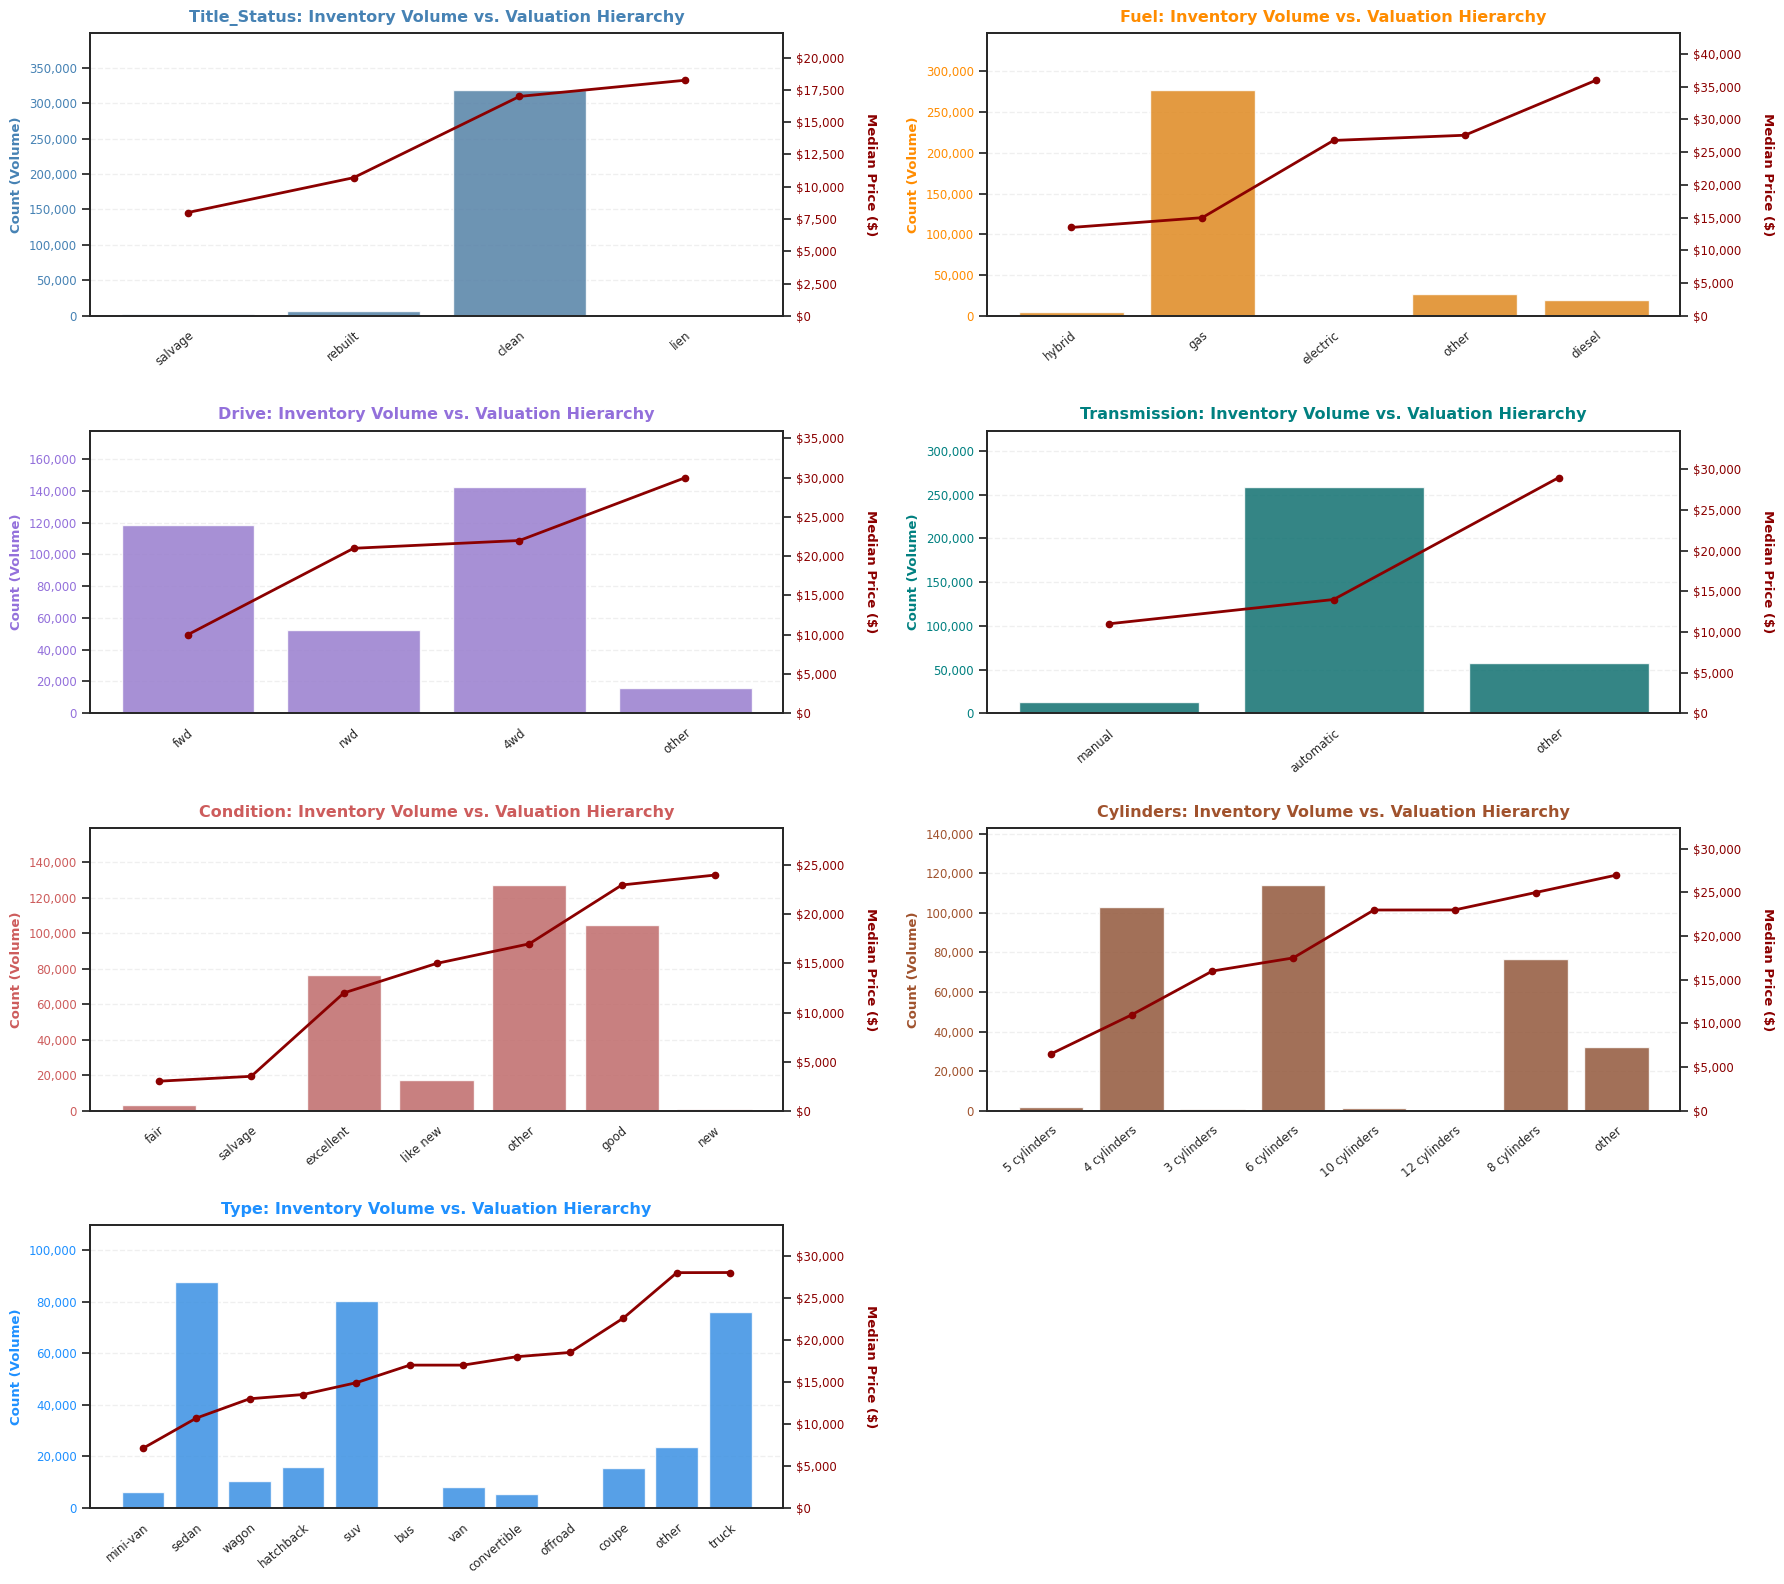

In [ ]:
sns.set_theme(style="white")

# Map each feature to its dedicated solid color for bars and color-coded titles
feature_colors = {
    "title_status": "steelblue",
    "fuel": "darkorange",
    "drive": "mediumpurple",
    "transmission": "teal",
    "condition": "indianred",
    "cylinders": "sienna",
    "type": "dodgerblue",
}

PRICE_LINE_COLOR = (
    "darkred"  # Unified dark red line for median price curve across all plots
)

fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes_flat = axes.flatten()

for ax_idx, (col, bar_color) in enumerate(feature_colors.items()):
  ax1 = axes_flat[ax_idx]

  # Sort data by median price ASCENDING so the price line rises smoothly from
  # left to right
  data_table = (
      low_card_summary[col]
      .sort_values(by="median_price", ascending=True)
      .reset_index(drop=True)
  )

  # Primary Left Axis: Single Solid Color Volume Bars
  sns.barplot(
      data=data_table,
      x=col,
      y="listing_count",
      color=bar_color,
      alpha=0.85,
      ax=ax1,
  )

  # Color-code title and left y-axis matching the feature's dedicated bar color
  ax1.set_title(
      f"{col.title()}: Inventory Volume vs. Valuation Hierarchy",
      fontsize=11.5,
      fontweight="bold",
      color=bar_color,
      pad=8,
  )
  ax1.set_ylabel(
      "Count (Volume)", fontsize=9.5, fontweight="bold", color=bar_color
  )
  ax1.tick_params(axis="y", labelcolor=bar_color, labelsize=8.5)
  ax1.yaxis.set_major_formatter("{x:,.0f}")
  ax1.set_ylim(0, data_table["listing_count"].max() * 1.25)
  ax1.set_xlabel("")
  ax1.grid(axis="y", linestyle="--", alpha=0.3)

  # Warning-free X-Axis Ticks & Slanted Labels
  ax1.set_xticks(
      ticks=range(len(data_table)),
      labels=data_table[col],
      rotation=40,
      ha="right",
      va="top",
      rotation_mode="anchor",
      fontsize=8.5,
  )

  # Secondary Right Axis: Rising Red Median Price Line
  ax2 = ax1.twinx()
  ax2.plot(
      np.arange(len(data_table)),
      data_table["median_price"],
      color=PRICE_LINE_COLOR,
      marker="o",
      linewidth=2.0,
      markersize=4.5,
      linestyle="-",
      label="Median Price ($)",
  )
  ax2.set_ylabel(
      "Median Price ($)",
      fontsize=9.5,
      fontweight="bold",
      color=PRICE_LINE_COLOR,
      rotation=-90,
      va="bottom",
      labelpad=14,
  )
  ax2.tick_params(axis="y", labelcolor=PRICE_LINE_COLOR, labelsize=8.5)
  ax2.yaxis.set_major_formatter("${x:,.0f}")
  ax2.set_ylim(0, data_table["median_price"].max() * 1.2)
  ax2.grid(False)

# Clean up unused 8th subplot slot
fig.delaxes(axes_flat[7])

plt.tight_layout(h_pad=1.8, w_pad=1.8)
plt.show()


### Insights: Low-Cardinality Categorical Features

* **`title_status`:** Clean titles represent 96.7% of listings, while non-clean titles have over 10,800 records to reliably capture salvage and rebuilt price discounts.
* **`fuel`:** Diesel vehicles have over 19,000 listings and hold the highest median price at \$35,995, commanding a substantial premium over standard gas models.
* **`drive`:** 4WD is the largest inventory segment at 43.2% and leads in median price at \$21,990, while FWD represents the lower-priced commuter segment at \$10,000.
* **`cylinders`:** Valuations scale directly with cylinder count, and 10-cylinder and 12-cylinder engines remain separate because their mean prices diverge by more than \$20,000.
* **`type`:** Pickups and trucks lead median valuations at \$27,999, whereas sedans and hatchbacks sit at the bottom of the pricing hierarchy.
* **`condition` & `transmission`:** The explicit other/unknown condition bucket sits cleanly between good and fair, while automatic transmission accounts for 78.4% of total inventory


### Summary: Phase 2.2 Categorical Feature Exploration

To recap:
* I dropped the high-cardinality `model` text column (18,029 messy trim variations) because `manufacturer` + `type` + `cylinders` + `fuel` + `drive` reconstructs the functional vehicle profile without adding 18,000 sparse columns.

*  I will one-hot encode **all** the remaining 9 categorical features (`state`, `manufacturer`, `type`, `drive`, `fuel`, `condition`, `title_status`, `transmission`, and `cylinders`), producing approximately **134 binary feature columns**.

I was worried that by adding >100 new features, I am making the feature set too large. To this end, I researched industry guidelines of what's the standard number to keep and when is it too much. For example, I could tell the 18,000 `model`s was too many but how do I know if the rest is okay?

According to standard statistical guidelines (such as *Harrell's Regression Modeling Strategies* and *Hair et al.'s Multivariate Data Analysis*), regression models require an observations-to-predictor ratio of at least **15:1 to 20:1** ($N/p \ge 20$) to estimate stable coefficients and prevent overfitting.
* With **329,752 clean rows** and **~134 features**, our dataset provides **over 2,400 observations per parameter**—far exceeding standard sample size thresholds.

Therefore, I feel more comfortable with going ahead with my plan and my DataFrame should be ready for the next step of training/test split and utlimately model generation.


In [ ]:
# save
filtered_cat_df_path = create_parquet_path('phase2_2_filtered_cat_features')

In [ ]:
filtered_cat_df = df.copy()
filtered_cat_df.to_parquet(filtered_cat_df_path)

print(f"Dataset saved to '{filtered_cat_df_path}'")
print(f"Shape: {filtered_cat_df.shape[0]:,} rows, {df.shape[1]} columns")

filtered_cat_df.info() # no model

Dataset saved to 'drive/MyDrive/all_data/11.1/data/output/phase2_2_filtered_cat_features.parquet'
Shape: 329,752 rows, 12 columns
<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         329752 non-null  int64  
 1   manufacturer  329752 non-null  object 
 2   condition     329752 non-null  object 
 3   cylinders     329752 non-null  object 
 4   fuel          329752 non-null  object 
 5   odometer      329752 non-null  float64
 6   title_status  329752 non-null  object 
 7   transmission  329752 non-null  object 
 8   drive         329752 non-null  object 
 9   type          329752 non-null  object 
 10  state         329752 non-null  object 
 11  vehicle_age   329752 non-null  float64
dtypes: float64(2), int64(1), object(9)
memory usage: 32.7+ MB


In [ ]:
# Check if 'df' is already loaded in memory; if not, read from parquet
prefix = 'Previously had'
if "filtered_cat_df" not in locals() or df is None:
  if os.path.exists(filtered_cat_df_path):
    filtered_cat_df = pd.read_parquet(filtered_cat_df_path)
    prefix = 'Loaded'
  else:
    raise FileNotFoundError(
        f'Parquet checkpoint not found at: {filtered_cat_df_path}'
      )

# Expected 329,752 but no model
print(f'{prefix} {len(filtered_cat_df):,} cleaned records. Ready for Phase 2.2!')

df = filtered_cat_df.copy()
df.info()

Previously had 329,752 cleaned records. Ready for Phase 2.2!
<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         329752 non-null  int64  
 1   manufacturer  329752 non-null  object 
 2   condition     329752 non-null  object 
 3   cylinders     329752 non-null  object 
 4   fuel          329752 non-null  object 
 5   odometer      329752 non-null  float64
 6   title_status  329752 non-null  object 
 7   transmission  329752 non-null  object 
 8   drive         329752 non-null  object 
 9   type          329752 non-null  object 
 10  state         329752 non-null  object 
 11  vehicle_age   329752 non-null  float64
dtypes: float64(2), int64(1), object(9)
memory usage: 32.7+ MB


### Addendum: Categorical Correlation using Dummies vs. OneHotEncoder

To establish a baseline during exploration, I want to use `pd.get_dummies()`  to calculate correlations between all categorical features and `price`, matching our earlier continuous variable analysis.

For model training, final one-hot encoding must be fitted **only on the training split (`X_train`)** to prevent data leakage. Applying dummy encoding across the entire dataset introduces target and vocabulary leakage and makes the model brittle. In real-world dealership operations, models must handle previously unseen inputs (such as a newly released manufacturer or unexpected trim).

Therefore, for Phase 3 preprocessing, I will encapsulate `OneHotEncoder` within Scikit-Learn's `ColumnTransformer` fitted exclusively on `X_train`. Using `handle_unknown='infrequent_if_exist'` guarantees that any new, unseen category encountered at inference time is safely routed to the learned infrequent/other baseline weight without causing pipeline crashes.


In [ ]:
all_cat_cols = df.select_dtypes(include="object").columns.tolist()
all_cat_cols

['manufacturer',
 'condition',
 'cylinders',
 'fuel',
 'title_status',
 'transmission',
 'drive',
 'type',
 'state']

In [ ]:
df_dummies = pd.get_dummies(
    df,
    columns=all_cat_cols,
    drop_first=True,  # Drops 1st category per feature to prevent
                      # multicollinearity (dummy variable trap)
    dtype=int,  # Produces 0/1 integers instead of boolean True/False
)

# Verify immutability of the original DataFrame
print(f"Original df shape: {df.shape} (Unchanged)")
print(f"New df_dummies shape: {df_dummies.shape}")
df_dummies.head()


Original df shape: (329752, 12) (Unchanged)
New df_dummies shape: (329752, 128)


,price,odometer,vehicle_age,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,...,state_sd,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy
0,33590,57923.0,12.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,22590,71229.0,16.0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,39590,19160.0,6.0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,30990,41124.0,9.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,15000,128000.0,13.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# doing the entire heat map would be huge, just do one correlation with price
# Note this is with ALL features not just cat
correlations_with_price = df_dummies.corrwith(df["price"]).sort_values(
    ascending=False
)
correlations_with_price.sample(5)

,0
state_ia,-0.027304
state_nm,0.019735
state_mt,0.049436
manufacturer_land rover,-0.003171
manufacturer_volkswagen,-0.063462


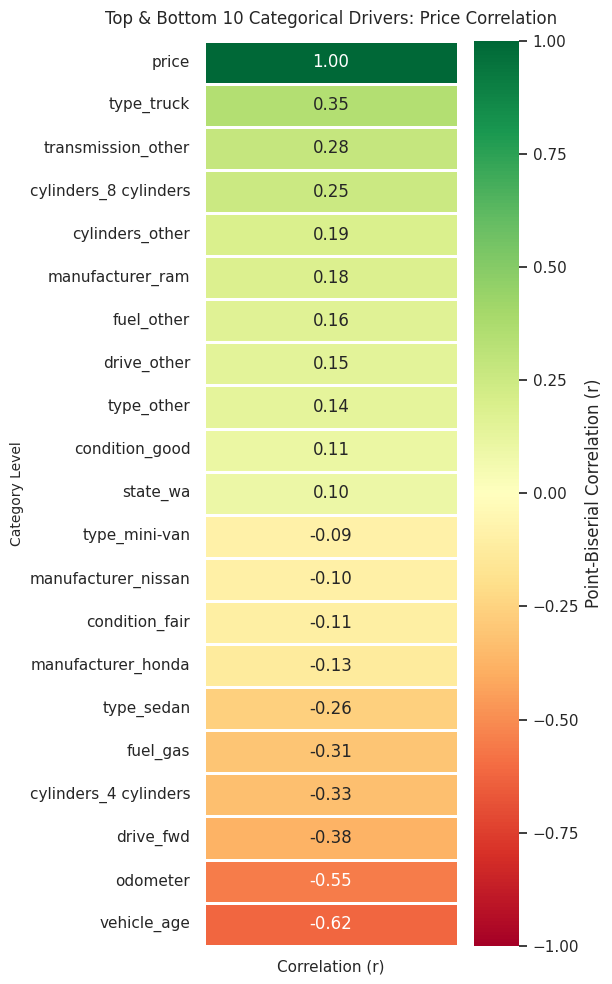

In [ ]:
top_pos = correlations_with_price.head(11) # first one is price itself
top_neg = correlations_with_price.tail(10)

top_drivers_series = pd.concat([top_pos, top_neg]).drop_duplicates()

# Convert 1D Series to 2D DataFrame for heatmap compatibility
top_drivers_df = top_drivers_series.to_frame(name="Correlation (r)")

# Dynamic color scaling: Symmetric limit anchored at zero
max_limit = max(abs(top_drivers_series.min()), abs(top_drivers_series.max()))

# Render Saturated Vertical Heatmap
plt.figure(figsize=(6, 10))

sns.heatmap(
    top_drivers_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",  # Red for discounts -> Yellow neutral -> Green for premiums
    vmin=-max_limit,
    vmax=max_limit,
    center=0,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Point-Biserial Correlation (r)"},
)

plt.title(
    "Top & Bottom 10 Categorical Drivers: Price Correlation",
    fontsize=12,
    pad=12,
)
plt.ylabel("Category Level", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# full print - very long
# print(correlations_with_price.to_string())

### Summary: Addendum Bivariate Linear Correlations

In Phase 2.1 and now, I observed that **`vehicle_age` ($r = -0.620$)** and **`odometer` ($r = -0.555$)** exert the strongest downward pressure on valuation and have the largest correlation with price in absolute value terms.

From this new heatmap, I can see that high-efficiency commuter attributes - such as front-wheel drive (`drive_fwd`, $r = -0.378$), 4-cylinder engines (`cylinders_4 cylinders`, $r = -0.334$), and sedans (`type_sedan`, $r = -0.260$)—exhibit the heaviest valuation discounts.

Conversely, heavy utility configurations like pickup trucks (`type_truck`, $r = +0.347$) and V8 engines (`cylinders_8 cylinders`, $r = +0.253$) serve as healthy positive price drivers.

Finally, I note somewhat counterintuitive positive price correlations across catch-all categories, including `transmission_other` ($r = +0.279$) and `fuel_other` ($r = +0.160$). Rather than representing baseline mechanical features, these could be acting as *confounding proxies* representing newer model-year inventory and unmapped specialty powertrains (such as plug-in hybrids, dual-clutch platforms, and heavy commercial chassis). It's possible that these `other` values were not distinctly classified during data collection.


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.